## Code to compare SED results to initial input spectra & photometry

This is how I initially get the SED plotted and loaded. 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
from synphot import SourceSpectrum, Observation, SpectralElement
from synphot.models import Empirical1D

In [2]:
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/GeneralFilters/"

#### Run this cell to get all the functions

In [17]:
def create_lookup_table(data_dir, wavelength_range=None, wavelength_bins=10000):
    """
    Load spectra from files, interpolate onto a common wavelength grid,
    and create both a DataFrame lookup table and a list of raw spectra.

    Parameters
    ----------
    data_dir : str
        Path to the directory containing spectra files.
    wavelength_range : tuple, optional
        (min, max) wavelength range for interpolation.
        If None, uses min/max across all input spectra.
    wavelength_bins : int
        Number of bins for common wavelength interpolation.

    Returns
    -------
    lookup_table : pd.DataFrame
        Interpolated flux grid (times x wavelengths).
    days_from_start : np.ndarray
        Time in days from the first MJD.
    common_wavelengths : np.ndarray
        Wavelength grid for interpolation.
    spectra_list : list of tuples
        Each entry is (time, wavelength_array, flux_array)
        with the raw values from the input file (no interpolation, no NaNs).
    """
    import os
    import numpy as np
    import pandas as pd

    # Collect all spectra files
    spectra_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".txt")])

    mjds = []
    wavelengths = []
    fluxes = []
    spectra_list = []

    for file in spectra_files:
        # Extract the MJD from the filename (assuming it starts with MJD)
        mjd = float(file.split("_")[0])
        mjds.append(mjd)

        # Load the data (assuming 3 columns: wavelength, flux, flux error)
        data = np.loadtxt(os.path.join(data_dir, file))
        wl = data[:, 0]
        fl = data[:, 1]

        wavelengths.append(wl)
        fluxes.append(fl)

        # Save raw spectrum (shift to relative days later)
        spectra_list.append((mjd, wl, fl))

    mjds = np.array(mjds)
    fluxes = np.array(fluxes, dtype=object)

    # Define common wavelength grid
    all_wavelengths = np.concatenate(wavelengths)
    wl_min = wavelength_range[0] if wavelength_range else np.nanmin(all_wavelengths)
    wl_max = wavelength_range[1] if wavelength_range else np.nanmax(all_wavelengths)
    common_wavelengths = np.linspace(wl_min, wl_max, wavelength_bins)

    # Interpolate flux onto the common wavelength grid
    fluxes_interpolated = []
    for i in range(len(fluxes)):
        # safer to use 0.0 outside, not NaN
        flux_interp = np.interp(common_wavelengths, wavelengths[i], fluxes[i],
                                left=0.0, right=0.0)
        fluxes_interpolated.append(flux_interp)

    fluxes_interpolated = np.array(fluxes_interpolated)

    # Subtract the minimum MJD to get days from start
    days_from_start = mjds - mjds.min()

    # Build DataFrame
    lookup_table = pd.DataFrame(
        fluxes_interpolated,
        index=days_from_start,          # Time as index
        columns=common_wavelengths      # Wavelength as columns
    )

    # Update spectra_list so times are days-from-start too
    spectra_list = [(mjd - mjds.min(), wl, fl) for mjd, wl, fl in spectra_list]

    return lookup_table, days_from_start, common_wavelengths, spectra_list

def synthetic_lightcurve(filter_file, system="abmag",
                         lookup_table=None, common_wavelengths=None,
                         spectra_list=None):
    """
    Compute a synthetic light curve by integrating spectra through a filter.

    Inputs (provide ONE of the two data pathways)
    --------------------------------------------
    - spectra_list: list of (time, wavelength, flux) tuples.
        * time: usually DAYS from start (float)
        * wavelength: Å array (monotonic)
        * flux: F_lambda array in erg s^-1 cm^-2 Å^-1
    - OR
    - lookup_table + common_wavelengths:
        * lookup_table: DataFrame [times x wavelengths] of F_lambda
        * common_wavelengths: 1D Å array

    Parameters
    ----------
    filter_file : str
        Two-column file (wavelength[Å], transmission[0–1]).
    system : str
        "flam", "abmag", "stmag", "vegamag", or "countrate".

    Returns
    -------
    times : np.ndarray
        Synthetic times (as provided: relative days or absolute MJD).
    lc : np.ndarray
        Synthetic values in the requested system.
    """
    filt_wave, filt_thru = np.loadtxt(filter_file, unpack=True)
    bandpass = SpectralElement(Empirical1D, points=filt_wave * u.AA, lookup_table=filt_thru)

    times, lc = [], []

    if spectra_list is not None:
        for (t, wl, fl) in spectra_list:
            m = np.isfinite(fl)
            if m.sum() == 0:
                times.append(t); lc.append(np.nan); continue
            src = SourceSpectrum(Empirical1D, points=wl[m] * u.AA,
                                 lookup_table=fl[m] * u.erg/u.s/(u.cm**2)/u.AA)
            obs = Observation(src, bandpass, force="taper")
            val = obs.countrate().value if system == "countrate" else obs.effstim(system).value
            times.append(t); lc.append(val)

    elif lookup_table is not None and common_wavelengths is not None:
        for i, t in enumerate(lookup_table.index):
            fl = lookup_table.iloc[i].values.astype(float)
            m = np.isfinite(fl)
            if m.sum() == 0:
                times.append(t); lc.append(np.nan); continue
            src = SourceSpectrum(Empirical1D, points=common_wavelengths[m] * u.AA,
                                 lookup_table=fl[m] * u.erg/u.s/(u.cm**2)/u.AA)
            obs = Observation(src, bandpass, force="taper")
            val = obs.countrate().value if system == "countrate" else obs.effstim(system).value
            times.append(t); lc.append(val)
    else:
        raise ValueError("Provide either spectra_list OR (lookup_table + common_wavelengths).")

    return np.array(times), np.array(lc)


def _auto_align_times(syn_times, obs_mjd, reference_mjd=None, syn_times_are_mjd=None):
    """
    Align observed MJD and synthetic times onto a common 'days since t0' axis.

    Heuristics:
      - If syn_times_are_mjd is provided, use it.
      - Else treat syn times as MJD if median(syn_times) > 10000.
      - If syn times are relative (days), set t0 = obs_mjd.min().
      - If syn times are absolute MJD, set t0 = min(obs_mjd.min(), syn_times.min()).
      - If reference_mjd is given, use that as t0.
    """
    syn_times = np.asarray(syn_times, dtype=float)
    obs_mjd = np.asarray(obs_mjd, dtype=float)

    if reference_mjd is not None:
        t0 = float(reference_mjd)
        # If user provides t0, assume syn_times are relative unless they look like MJD
        if syn_times_are_mjd is None:
            syn_times_are_mjd = (np.nanmedian(syn_times) > 10000)
    else:
        if syn_times_are_mjd is None:
            syn_times_are_mjd = (np.nanmedian(syn_times) > 10000)

        if syn_times_are_mjd:
            t0 = np.nanmin([np.nanmin(obs_mjd), np.nanmin(syn_times)])
        else:
            t0 = np.nanmin(obs_mjd)

    obs_time = obs_mjd - t0
    syn_time = syn_times - (t0 if syn_times_are_mjd else 0.0)
    return syn_time, obs_time, t0

def compare_lightcurves_mag(filter_file, data_file, 
                            lookup_table=None, common_wavelengths=None,
                            spectra_list=None, system="abmag", mjd0=None):
    """
    Compare synthetic lightcurve in AB mag to observed photometry (in mags).
    """
    # --- synthetic lightcurve ---
    syn_times, syn_mags = synthetic_lightcurve(
        filter_file, system=system,
        lookup_table=lookup_table,
        common_wavelengths=common_wavelengths,
        spectra_list=spectra_list
    )

    # --- observed photometry ---
    df = pd.read_csv(data_file)  # comma is default

    # Extract bandname from filter file (e.g., "Swope_g.dat" -> "Swope_g")
    bandname = os.path.basename(filter_file).replace(".dat", "")
    
    obs = df[df["band"] == bandname].copy()
    if obs.empty:
        raise ValueError(f"No photometry found for band '{bandname}' in {data_file}")

    # time axis: relative to chosen mjd0
    if mjd0 is None:
        mjd0 = obs["MJD"].min()  # <-- FIXED

    obs["time"] = obs["MJD"] - mjd0
    syn_times = syn_times - 0.0  # synthetic times are already days-from-start

    # --- plotting ---
    plt.figure(figsize=(7,5))
    plt.errorbar(obs["time"], obs["Mag"], yerr=obs["Mag_err"],
                 fmt="o", label="Observed", color="tab:blue")
    plt.plot(syn_times, syn_mags, "-", label="Synthetic", color="tab:orange")

    plt.xlabel("Time since {:.2f} MJD (days)".format(mjd0))
    plt.ylabel("AB mag")
    plt.title(f"Lightcurve in {bandname}")
    plt.gca().invert_yaxis()  # brighter = up
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_spectrum(time_from_start, lookup_table, wavelengths):
    """
    Plot a spectrum (flux vs wavelength) for a given time.
    """
    # Find the closest time in the DataFrame
    closest_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - time_from_start))]
    flux = lookup_table.loc[closest_time]

    # Plot the spectrum
    plt.figure(figsize=(8, 5))
    plt.plot(wavelengths, flux, label=f"Time = {closest_time:.2f} days")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Spectrum at Time {:.2f} days".format(closest_time))
    plt.legend()
    plt.grid()
    plt.show()


def plot_lightcurve(wavelength, lookup_table):
    """
    Plot a light curve (flux vs time) for a given wavelength.
    """
    # Find the closest wavelength in the DataFrame
    closest_wavelength = lookup_table.columns[np.argmin(np.abs(lookup_table.columns - wavelength))]
    flux = lookup_table[closest_wavelength]

    # Plot the light curve
    plt.figure(figsize=(8, 5))
    plt.scatter(lookup_table.index, flux, label=f"Wavelength = {closest_wavelength:.2f} Å")
    plt.xlabel("Time (days from start)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Lightcurve at Wavelength {:.2f} Å".format(closest_wavelength))
    plt.legend()
    plt.grid()
    plt.show()


def plot_sed_evolution(
    lookup_table,
    common_wavelengths,
    days_from_start,
    vmin=None,
    vmax=None
):
    """
    Create a 2D plot of spectral density evolution (time vs wavelength vs flux).

    Parameters
    ----------
    lookup_table : pd.DataFrame
        Flux values with time as index and wavelengths as columns.
    common_wavelengths : np.ndarray
        The wavelength grid used for interpolation.
    days_from_start : np.ndarray
        Time in days from the first detection.
    vmin, vmax : float, optional
        Min/max flux values for color scaling. If None, determined from the data.
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    import numpy as np

    flux_values = lookup_table.values

    # if not provided, compute automatically
    if vmin is None:
        vmin = np.nanmin(flux_values[flux_values > 0])  # smallest positive flux
    if vmax is None:
        vmax = np.nanmax(flux_values)

    plt.figure(figsize=(10, 6))
    plt.imshow(
        flux_values.T,
        aspect='auto',
        extent=[days_from_start.min(), days_from_start.max(),
                common_wavelengths.min(), common_wavelengths.max()],
        origin='lower',
        cmap='viridis',
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(label=r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.xlabel("Days from first detection")
    plt.ylabel("Wavelength (Å)")
    plt.title("SED Evolution")
    plt.show()

def compare_sed_and_original_spectrum(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.,
    z = 0.00984  # tolerance for including multiple spectra
):
    """
    Plot SED spectrum and original or smoothed input spectrum at the closest time 
    to mjd_query. If time_window > 0, plot all spectra within ±time_window of mjd_query.
    """
    import matplotlib.pyplot as plt
    import os
    import numpy as np

    # --- SED spectrum ---
    sed_time = mjd_query - mjd0
    closest_sed_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - sed_time))]
    sed_flux = lookup_table.loc[closest_sed_time].values

    # --- Choose list and directory based on mode ---
    if mode == "smoothed":
        list_file = list_file.replace("1_spec_lists_original", "2_spec_lists_smoothed")
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
    else:
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"

    # --- Load list of spectra ---
    orig_paths, orig_mjds = [], []
    with open(list_file) as f:
        for line in f:
            if line.strip() == "" or line.startswith("#"):
                continue
            parts = line.split()
            if mode == "smoothed":
                if len(parts) < 3:
                    continue
                try:
                    orig_mjds.append(float(parts[0]))
                    orig_paths.append(parts[2])
                except Exception:
                    continue
            else:
                if len(parts) < 3:
                    continue
                try:
                    orig_paths.append(parts[0])
                    orig_mjds.append(float(parts[-1]))
                except Exception:
                    continue
    if not orig_paths or not orig_mjds:
        print(f"No valid spectra found in {list_file}")
        return
    orig_mjds = np.array(orig_mjds)

    # --- Select spectra ---
    if time_window > 0:
        idxs = np.where(np.abs(orig_mjds - mjd_query) <= time_window)[0]
        if len(idxs) == 0:
            idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]
    else:
        idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # Plot SED first
    ax.plot(
        wavelengths, 50*sed_flux,
        label=f"SED (t={closest_sed_time + mjd0:.6f} MJD)",  # full precision
        color="black",
        alpha=0.75
    )

    label = "Smoothed" if mode == "smoothed" else "Original"

    # Color cycle for multiple spectra
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for j, idx in enumerate(idxs):
        orig_path = orig_paths[idx]
        orig_mjd = orig_mjds[idx]

        # --- Fix local path if needed ---
        if orig_path.startswith("/data/1_spec_original/") or orig_path.startswith("/data/2_spec_smoothed/"):
            if mode == "smoothed":
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
                orig_path = os.path.join(local_base, orig_path.replace("/data/2_spec_smoothed/", ""))
            else:
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
                orig_path = os.path.join(local_base, orig_path.replace("/data/1_spec_original/", ""))
        elif not orig_path.startswith("/"):
            orig_path = os.path.join(original_spec_dir, orig_path)
        orig_path = os.path.expanduser(orig_path)

        # --- Load spectrum ---
        try:
            orig_data = np.loadtxt(orig_path)
            orig_wl = orig_data[:, 0]
            orig_flux = orig_data[:, 1]
        except Exception as e:
            print(f"Could not load spectrum: {orig_path}\n{e}")
            continue
        
        if z > 0.0:
            orig_wl = orig_wl / (1 + z)
            orig_flux = orig_flux * (1 + z)
        
        # --- Plot spectrum ---
        ax.plot(
            orig_wl, orig_flux,
            label=f"{label} (t={orig_mjd:.6f} MJD)",  # full precision
            color=color_cycle[j % len(color_cycle)],
            alpha=0.8
        )
    #ax.set_ylim(0, 8e-17)

    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    ax.set_title(f"SED vs {label} Spectrum(s) near {mjd_query:.2f} MJD")
    ax.legend()
    ax.grid()
    plt.show()

In [4]:
# ...existing code...
def compare_sed_spectrum_test(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.,
    z = 0.00984  # tolerance for including multiple spectra
):
    """
    Plot SED spectrum and original, smoothed, or mangled input spectrum at the closest time
    to mjd_query. If time_window > 0, plot all spectra within ±time_window of mjd_query.

    mode: "original", "smoothed", or "mangled"
    """
    import matplotlib.pyplot as plt
    import os
    import numpy as np

    # --- SED spectrum ---
    sed_time = mjd_query - mjd0
    closest_sed_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - sed_time))]
    sed_flux = lookup_table.loc[closest_sed_time].values

    # --- Choose list and directory based on mode ---
    if mode == "smoothed":
        if list_file == None:
            list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_lists_smoothed/AT2017gfo.list"
        list_file = list_file.replace("1_spec_lists_original", "2_spec_lists_smoothed")
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
    elif mode == "mangled":
        # default mangled directory
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/mangled_spectra"
        # If no list_file or list_file doesn't exist, build list by scanning the directory
        if list_file is None or not os.path.exists(list_file):
            orig_paths = sorted([f for f in os.listdir(original_spec_dir) if f.endswith(".txt")])
            orig_mjds = []
            for fname in orig_paths:
                try:
                    orig_mjds.append(float(fname.split("_")[0]))
                except Exception:
                    orig_mjds.append(np.nan)
        else:
            # fall back to parsing provided list_file similarly to "original"
            orig_paths, orig_mjds = [], []
            with open(list_file) as f:
                for line in f:
                    if line.strip() == "" or line.startswith("#"):
                        continue
                    parts = line.split()
                    if len(parts) < 1:
                        continue
                    # try to parse path and MJD-like token at end
                    try:
                        orig_paths.append(parts[0])
                        orig_mjds.append(float(parts[-1]))
                    except Exception:
                        continue
    else:
        # original mode (default)
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"

        orig_paths, orig_mjds = [], []
        with open(list_file) as f:
            for line in f:
                if line.strip() == "" or line.startswith("#"):
                    continue
                parts = line.split()
                if mode == "smoothed":
                    if len(parts) < 3:
                        continue
                    try:
                        orig_mjds.append(float(parts[0]))
                        orig_paths.append(parts[2])
                    except Exception:
                        continue
                else:
                    if len(parts) < 1:
                        continue
                    try:
                        orig_paths.append(parts[0])
                        orig_mjds.append(float(parts[-1]))
                    except Exception:
                        continue

    # make sure we have lists
    try:
        orig_mjds = np.array(orig_mjds)
    except Exception:
        orig_mjds = np.array([])

    if not orig_paths or orig_mjds.size == 0:
        print(f"No valid spectra found in {list_file} or {original_spec_dir}")
        return

    # --- Select spectra ---
    if time_window > 0:
        idxs = np.where(np.abs(orig_mjds - mjd_query) <= time_window)[0]
        if len(idxs) == 0:
            idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]
    else:
        idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # Plot SED first
    ax.plot(
        wavelengths, sed_flux,
        label=f"SED (t={closest_sed_time + mjd0:.6f} MJD)",
        color="black",
        alpha=0.75
    )

    label = "Smoothed" if mode == "smoothed" else ("Mangled" if mode == "mangled" else "Original")

    # Color cycle for multiple spectra
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for j, idx in enumerate(idxs):
        orig_path = orig_paths[idx]
        orig_mjd = orig_mjds[idx]

        # --- Fix local path if needed ---
        if orig_path.startswith("/data/1_spec_original/") or orig_path.startswith("/data/2_spec_smoothed/"):
            if mode == "smoothed":
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
                orig_path = os.path.join(local_base, orig_path.replace("/data/2_spec_smoothed/", ""))
            else:
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
                orig_path = os.path.join(local_base, orig_path.replace("/data/1_spec_original/", ""))
        elif not orig_path.startswith("/"):
            orig_path = os.path.join(original_spec_dir, orig_path)
        orig_path = os.path.expanduser(orig_path)

        # --- Load spectrum ---
        try:
            orig_data = np.loadtxt(orig_path)
            orig_wl = orig_data[:, 0]
            orig_flux = orig_data[:, 1]
        except Exception as e:
            print(f"Could not load spectrum: {orig_path}\n{e}")
            continue

        if z > 0.0:
            orig_wl = orig_wl / (1 + z)
            orig_flux = orig_flux * (1 + z)

        # --- Plot spectrum ---
        ax.plot(
            orig_wl, orig_flux,
            label=f"{label} (t={orig_mjd:.6f} MJD)",
            color=color_cycle[j % len(color_cycle)],
            alpha=0.8
        )

    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    ax.set_title(f"SED vs {label} Spectrum(s) near {mjd_query:.2f} MJD")
    ax.legend()
    ax.grid()
    plt.show()
# ...existing code...

In [5]:
data_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/as_observed"

In [6]:
lookup_table, days_from_start, common_wavelengths, spectra_list = create_lookup_table(data_dir)

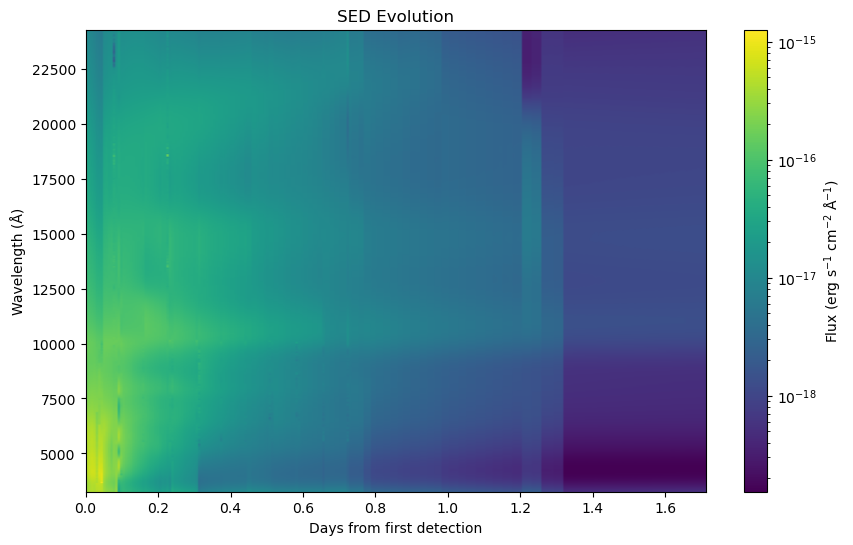

In [7]:
plot_sed_evolution(lookup_table, common_wavelengths, days_from_start)

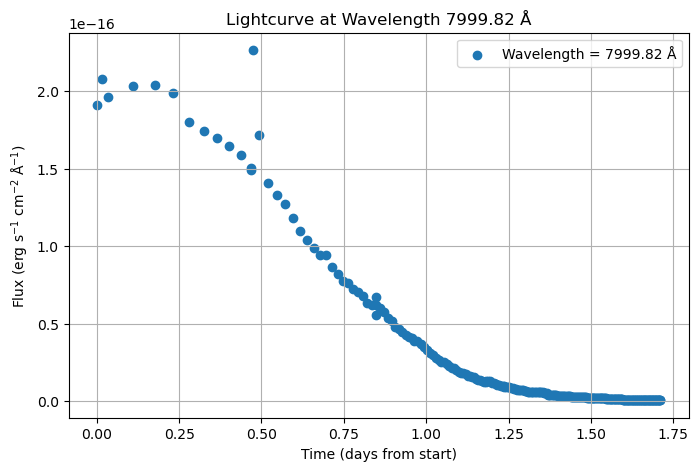

In [8]:
plot_lightcurve(8000, lookup_table)

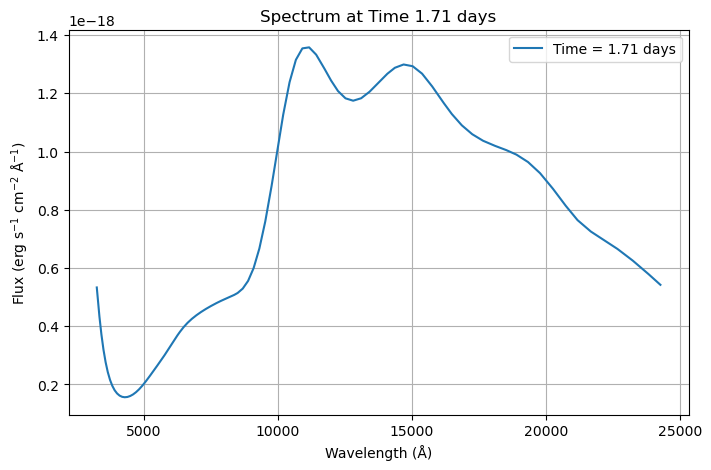

In [9]:
plot_spectrum(2, lookup_table, common_wavelengths)

In [10]:
compare_lightcurves_mag(
    FILTER_PATH+"FLAMINGOS-2_Ks.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

  points: [ 6476.592  6564.462  6653.524  6743.795  6835.291  6928.027  7022.022
  7117.293  7213.856  7311.729  7410.929  7511.476  7613.387  7716.681
  7821.376  7927.49   8035.046  9318.953  9445.386  9573.535  9703.423
  9835.073  9968.51  11253.92  11406.6   11561.36  11718.22  11877.2
 13590.66  13775.04  13961.93  14151.36  14537.96  14735.2   14935.12
 15137.74  15343.12  15551.3   16860.96  17321.58  17556.58  19820.45
 20089.36  20361.92  20638.18  22987.53  23299.41  23615.52  23935.92
 24260.67 ]
  lookup_table: [-5.34804367e-02 -9.57122994e-02 -1.21080657e-01 -1.33246186e-01
 -1.35373763e-01 -1.30163545e-01 -1.19885744e-01 -1.06415621e-01
 -9.12703126e-02 -7.56451649e-02 -6.04499821e-02 -4.63445933e-02
 -3.37731541e-02 -2.29972724e-02 -1.41271681e-02 -7.15117798e-03
 -1.96298349e-03 -3.25038881e-04 -5.36760754e-04 -5.60664431e-04
 -4.47702397e-04 -2.54321125e-04 -3.42497380e-05 -1.51010478e-05
 -3.08217317e-05 -2.65924755e-05 -1.38060912e-05 -2.52196869e-06
 -2.90079318e-0

DuplicateWavelength: ('Wavelength array contains duplicate entries', 'Invalid entries at or about row: [    0     1     3     4     6     7     9    10    12    13    15    16\n    18    19    21    22    24    25    27    28    30    31    33    34\n    36    37    39    40    42    43    45    46    48    49    51    52\n    54    55    57    58    60    61    63    64    66    67    69    70\n    72    73    75    76    78    79    81    82    84    85    87    88\n    90    91    93    94    96    97    99   100   102   103   105   106\n   108   109   111   112   114   115   117   118   120   121   123   124\n   126   127   129   130   132   133   135   136   138   139   141   142\n   144   145   147   148   150   151   153   154   156   157   159   160\n   162   163   165   166   168   169   171   172   174   175   177   178\n   180   181   183   184   186   187   189   190   192   193   195   196\n   198   199   201   202   204   205   207   208   210   211   213   214\n   216   

  points: [11377.44 11417.05 11456.66 11496.27 11535.88 11575.49 11615.1  11654.71
 11694.32 11733.93 11773.54 11813.15 11852.76 11892.37 11931.98 11971.59
 12011.2  12050.81 12090.42 13437.17 13476.78 13516.39 13556.   13595.61
 13635.22 13674.83 13714.44 13754.05 13793.66 13833.27 13872.88 13912.49
 13952.1  13991.71 14031.32 14070.93 14110.54 14150.15 14189.76 14229.37
 14268.98 14308.59 14348.2  14387.81 14427.42 14467.03 14506.64 14546.25
 14585.87 14625.48 14665.09 14704.7 ]
  lookup_table: [-1.42873727e-08 -1.58113066e-07 -2.70267063e-07 -3.55104545e-07
 -4.16528107e-07 -4.58026333e-07 -4.82705255e-07 -4.93314110e-07
 -4.92262049e-07 -4.81624058e-07 -4.63135206e-07 -4.38169496e-07
 -4.07699158e-07 -3.72225162e-07 -3.31661983e-07 -2.85145734e-07
 -2.30709606e-07 -1.64724533e-07 -8.09131949e-08 -1.51125371e-07
 -2.06067245e-06 -3.73634162e-06 -5.18811507e-06 -6.42671975e-06
 -7.46343577e-06 -8.30997289e-06 -8.97835988e-06 -9.48086656e-06
 -9.82994320e-06 -1.00381442e-05 -1.0118029

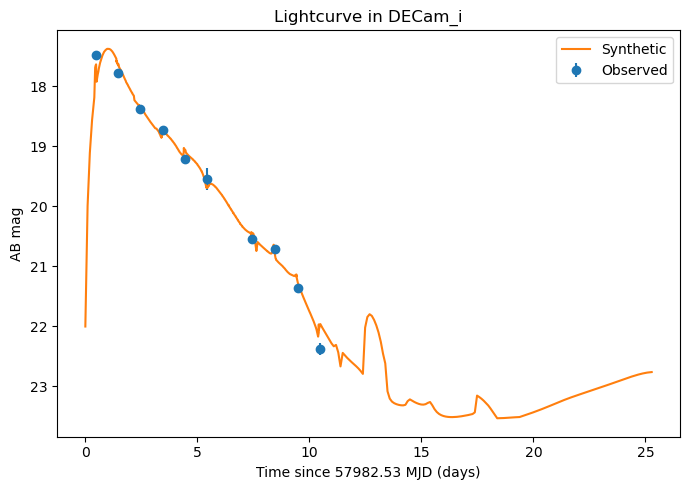

In [53]:
compare_lightcurves_mag(
    FILTER_PATH+"DECam_i.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

In [10]:
compare_lightcurves_mag(
    FILTER_PATH+"DECam_i.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

DuplicateWavelength: ('Wavelength array contains duplicate entries', 'Invalid entries at or about row: [   0    2    4    6    8   10 9361 9363 9365 9367 9369 9371 9373 9375\n 9377 9379 9381 9383 9385 9387 9389 9391 9393 9395 9397 9399 9401 9403\n 9405 9407 9409 9411 9413 9415 9417 9419 9421 9423 9425 9427 9429 9431\n 9433 9435 9437 9439 9441 9443 9445 9447 9449 9451 9453 9455 9457 9459\n 9461 9463 9465 9467 9469 9471]')

In [11]:
explosion_mjd = 57982.52851852
data_file = COCO_PATH + "Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat"
df = pd.read_csv(data_file)
print("photometry earliest MJD (all bands):", df["MJD"].min())
print("photometry earliest MJD (DECam_i band):", df[df["band"]=="DECam_i"]["MJD"].min())

photometry earliest MJD (all bands): 57982.981
photometry earliest MJD (DECam_i band): 57983.003


In [9]:
# synthetic times (days-from-first-spectrum) from your spectra_list
syn_times, syn_mags = synthetic_lightcurve(FILTER_PATH + "DECam_i.dat",
                                           system="abmag",
                                           spectra_list=spectra_list)

# infer the first-spectrum MJD from the spectra filenames in data_dir
spec_dir = data_dir  # same variable you used for create_lookup_table
mjd_ref = min(float(fname.split("_")[0]) for fname in os.listdir(spec_dir) if fname.endswith(".txt"))
print("first-spectrum (mjd_ref):", mjd_ref)
print("syn_times (days from mjd_ref) first values:", syn_times[:6])

  points: [ 3653.443  3693.053  3732.664  3772.274  3811.884  3851.494  3891.105
  4564.479  4604.089  4643.699  4683.309  4722.919  4762.53   4802.14
  4841.75   4881.36   4920.971  4960.581  5000.191  5039.801  5079.412
  5119.022  5158.632  5198.242  5237.853  5277.463  5317.073  6743.041
  6782.652  6822.262  6861.872  6901.482  6941.093  6980.703  7020.313
 10624.84  10664.45  10704.06  10743.67  10783.28  10822.89  10862.5
 10902.11  10941.72  10981.33  11020.94  11060.55  11100.16  11139.77
 11179.38  11219.    11258.61  11298.22  11337.83  11377.44  11417.05
 11456.66  11496.27  11535.88  11575.49  11615.1   11654.71  11694.32
 11733.93  11773.54  11813.15  11852.76  11892.37  11931.98  11971.59
 12011.2   12050.81  12090.42  12130.03  12169.64  12209.25  12248.86
 12288.47  12328.08  12367.69  12407.3   12446.91  12486.52  12526.13
 12565.74  12605.35  12644.96  12684.57  12724.18  12763.79  12803.4
 12843.01  12882.62  12922.24  12961.85  13001.46  13041.07  13080.68
 13120.2

first-spectrum (mjd_ref): 57982.58
syn_times (days from mjd_ref) first values: [0.       0.100192 0.200385 0.300577 0.400769 0.43825 ]


In [10]:
# convert to absolute MJD and then to days since explosion
syn_times_mjd = syn_times + mjd_ref
syn_times_since_explosion = syn_times_mjd - explosion_mjd
print("syn_times (MJD) first values:", syn_times_mjd[:6])
print("syn_times since explosion (days) first values:", syn_times_since_explosion[:6])

syn_times (MJD) first values: [57982.58     57982.680192 57982.780385 57982.880577 57982.980769
 57983.01825 ]
syn_times since explosion (days) first values: [0.05148148 0.15167348 0.25186648 0.35205848 0.45225048 0.48973148]


In [75]:
df = pd.read_csv(COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat")
obs = df[df["band"] == 'Swope_i'].copy()

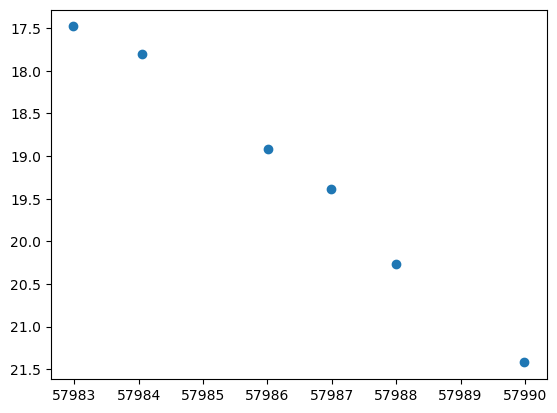

In [76]:
plt.scatter(obs['MJD'], obs['Mag'])
plt.gca().invert_yaxis()

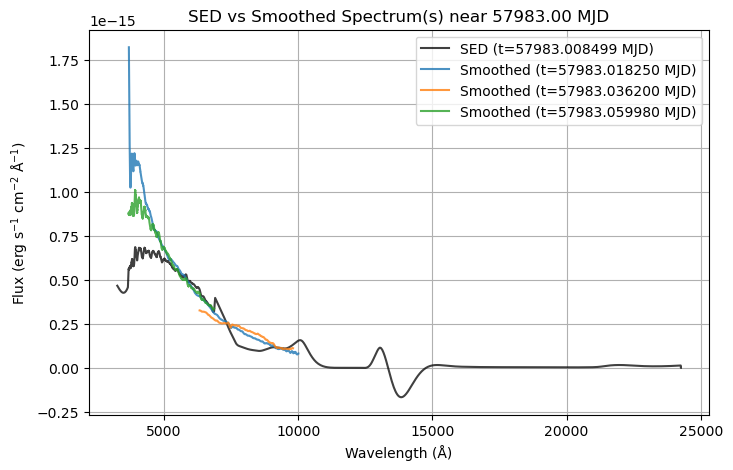

In [54]:
compare_sed_and_original_spectrum(
    mjd_query=57983.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

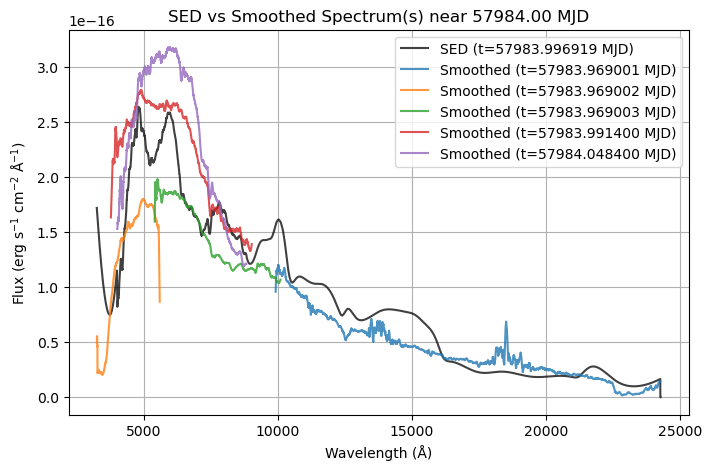

In [55]:
compare_sed_and_original_spectrum(
    mjd_query=57984.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

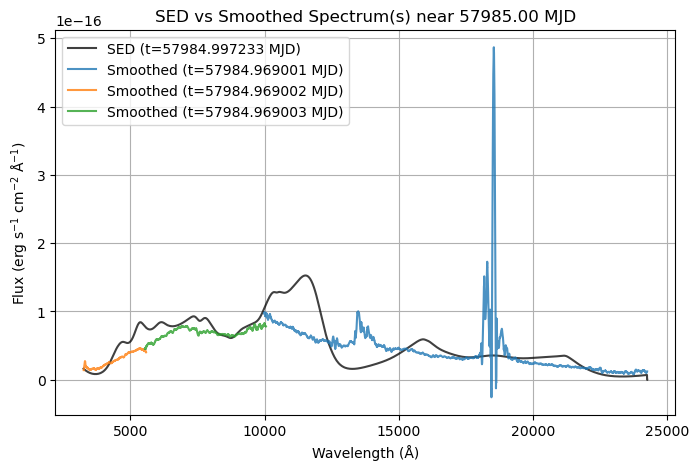

In [56]:
compare_sed_and_original_spectrum(
    mjd_query=57985.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

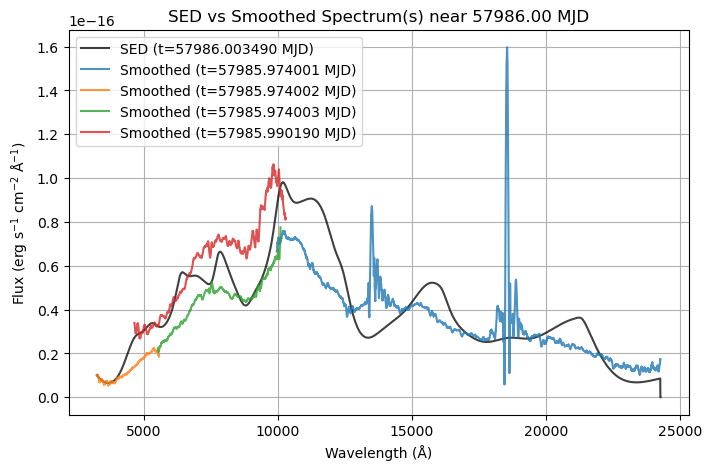

In [57]:
compare_sed_and_original_spectrum(
    mjd_query=57986.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

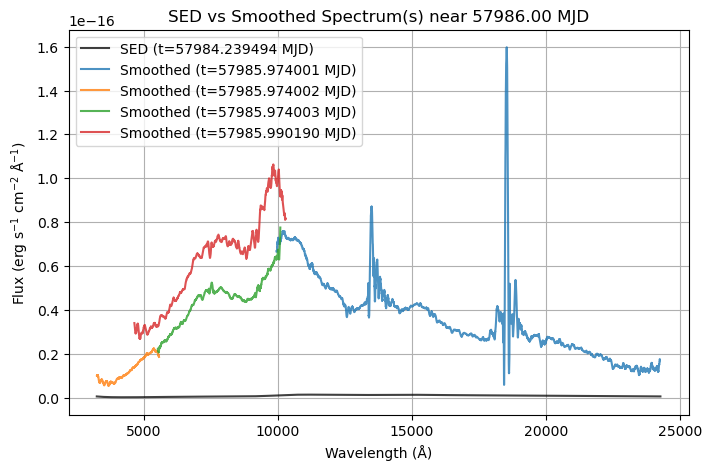

In [12]:
compare_sed_and_original_spectrum(
    mjd_query=57986.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

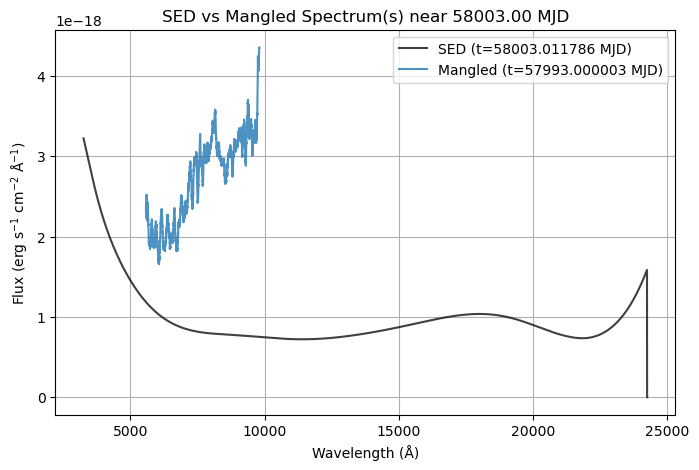

In [58]:
#THIS IS THE CORRECT TESTING CELL

compare_sed_spectrum_test(
    mjd_query=58003.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file=None,
    #57982.52851852
    #list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='mangled',
    time_window=0.5  # will include all spectra within ±0.5 days
)

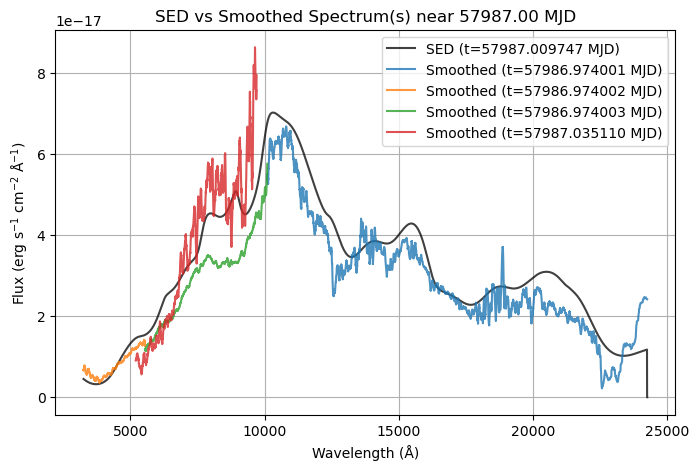

In [59]:
compare_sed_and_original_spectrum(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

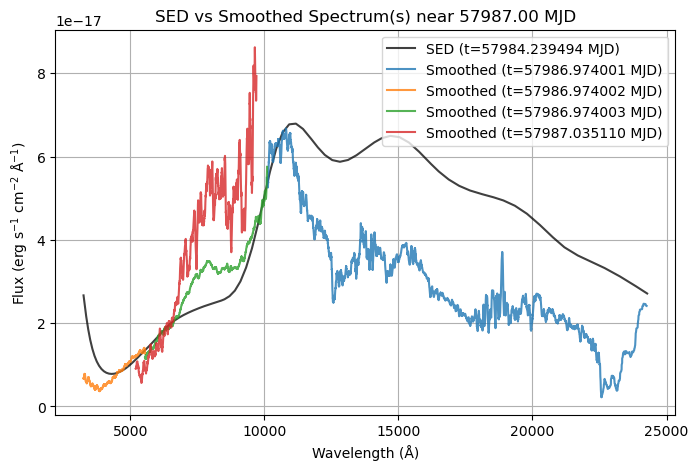

In [20]:
compare_sed_and_original_spectrum(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

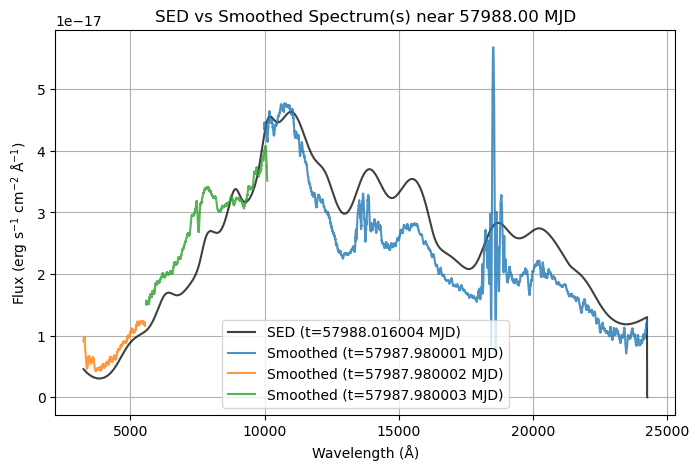

In [60]:
compare_sed_and_original_spectrum(
    mjd_query=57988.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

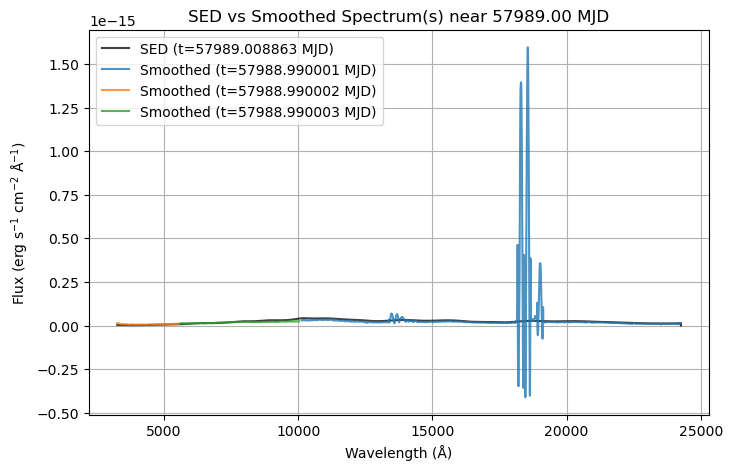

In [21]:
compare_sed_and_original_spectrum(
    mjd_query=57989.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

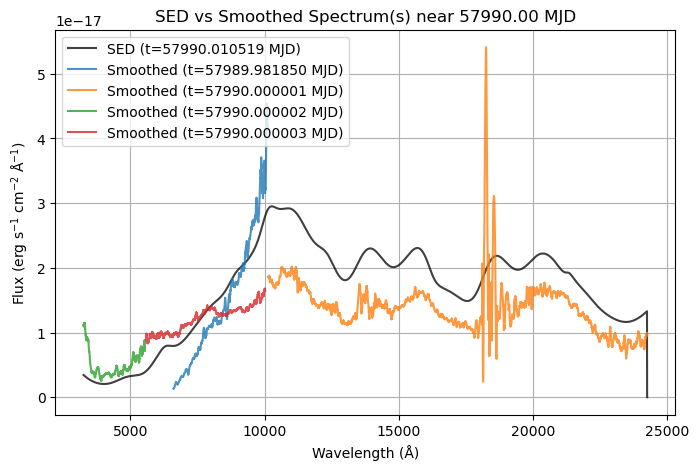

In [22]:
compare_sed_and_original_spectrum(
    mjd_query=57990.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

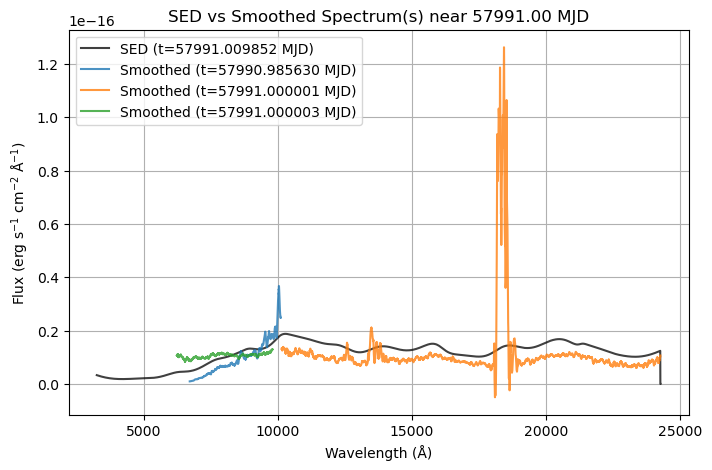

In [23]:
compare_sed_and_original_spectrum(
    mjd_query=57991.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5 ) # will include all spectra within ±0.5 days

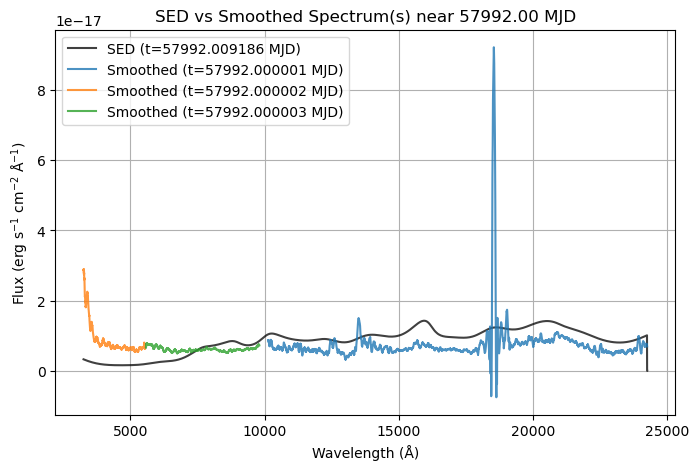

In [24]:
compare_sed_and_original_spectrum(
    mjd_query=57992.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5 ) # will include all spectra within ±0.5 days

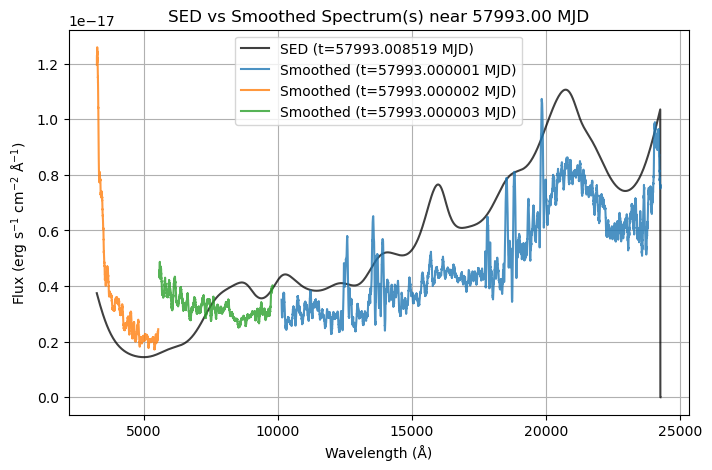

In [25]:
compare_sed_and_original_spectrum(
    mjd_query=57993.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5 ) # will include all spectra within ±0.5 days

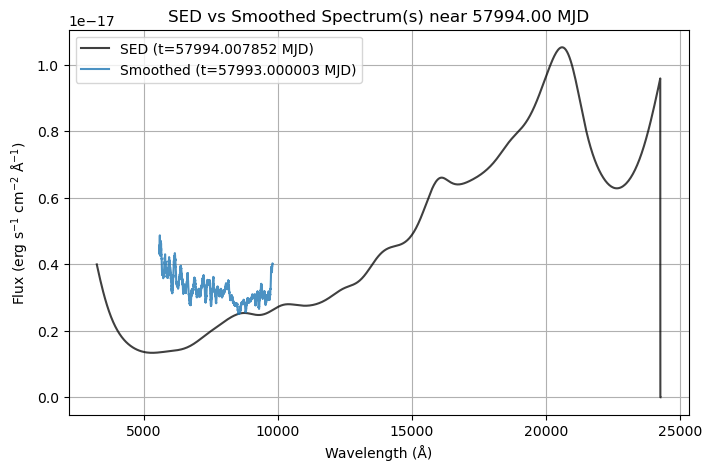

In [26]:
compare_sed_and_original_spectrum(
    mjd_query=57994.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5 ) # will include all spectra within ±0.5 days

## testing lightcurve function that plots multiple at once

In [64]:
def compare_lightcurves_mag(
    filter_files,
    data_file,   # a single photometry file with all filters
    lookup_table=None,
    common_wavelengths=None,
    spectra_list=None,
    system="abmag",
    mjd0=None
):
    """
    Compare synthetic lightcurves in AB mag to observed photometry, 
    for one or multiple filters.

    Parameters
    ----------
    filter_files : str or list of str
        Filter transmission curve files (e.g., ["Swope_g.dat", "FourStar_H.dat"]).
    data_file : str
        CSV with observed photometry (must contain 'MJD','Mag','Mag_err','band').
    lookup_table, common_wavelengths, spectra_list : see synthetic_lightcurve
    system : str
        Magnitude system ("abmag", "vegamag", etc.).
    mjd0 : float, optional
        Reference MJD. If None, uses the earliest observed MJD across all filters.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import os

    # normalize input
    if isinstance(filter_files, str):
        filter_files = [filter_files]

    # load observed data
    df = pd.read_csv(data_file)

    # decide mjd0 if not provided
    if mjd0 is None:
        mjd0 = df["MJD"].min()

    fig, ax = plt.subplots(figsize=(8, 6))
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for k, filter_file in enumerate(filter_files):
        # band name inferred from filter file name
        bandname = os.path.basename(filter_file).replace(".dat", "")

        # synthetic lightcurve for this filter
        syn_times, syn_mags = synthetic_lightcurve(
            filter_file,
            system=system,
            lookup_table=lookup_table,
            common_wavelengths=common_wavelengths,
            spectra_list=spectra_list
        )
        syn_times = syn_times  # already in days-from-start

        # pick a color for this filter
        color = color_cycle[k % len(color_cycle)]

        # observed data for this filter
        obs = df[df["band"] == bandname].copy()
        if obs.empty:
            print(f"⚠️ No photometry found for band '{bandname}' in {data_file}")
            continue
        obs["time"] = obs["MJD"] - mjd0

        # plot observed
        ax.errorbar(
            obs["time"], obs["Mag"], yerr=obs["Mag_err"],
            fmt="o", label=f"Obs {bandname}",
            color=color, alpha=0.9
        )

        # plot synthetic
        ax.plot(
            syn_times, syn_mags,
            "-", label=f"SED {bandname}",
            color=color, lw=2, alpha=0.7
        )

    ax.set_xlabel(f"Time since {mjd0:.2f} MJD (days)")
    ax.set_ylabel("AB mag")
    ax.set_title("Observed vs Synthetic Lightcurves")
    ax.invert_yaxis()  # brighter = up
    ax.legend()
    fig.tight_layout()
    plt.show()

In [65]:
compare_lightcurves_mag(
    filter_files=["Swope_i.dat", "Swope_w.dat", "FourStar_H.dat"],
    data_file="photometry.csv",
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=spectra_list,
    system="abmag"
)

FileNotFoundError: [Errno 2] No such file or directory: 'photometry.csv'

In [97]:
import numpy as np

wavelengths = np.arange(1500, 25001, 10)  # 1500–25000 Å in steps of 100
phases = np.arange(0, 201, 1)              # 0–200 days
flat_value = 1.0

with open("prior_flat.txt", "w") as f:
    for wl in wavelengths:
        for ph in phases:
            f.write(f"{wl:.1f},{ph:.1f},{flat_value:.2f}\n")

## testing plotting mangled spectra

In [49]:
def compare_sed_and_spectra(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file=None,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.,
    z=0.00984
):
    """
    Plot SED spectrum and original, smoothed, or mangled input spectrum at the closest time 
    to mjd_query. If time_window > 0, plot all spectra within ±time_window of mjd_query.

    Parameters
    ----------
    mjd_query : float
        MJD to query for the spectrum.
    lookup_table : pd.DataFrame
        SED lookup table with time as index and wavelengths as columns.
    wavelengths : np.ndarray
        Common wavelength grid.
    mjd0 : float
        Reference MJD for SED times.
    list_file : str, optional
        Path to the list file for original or smoothed spectra. Not needed for mangled.
    original_spec_dir : str, optional
        Directory containing the spectra files. Defaults based on mode.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, creates a new figure.
    mode : str
        "original", "smoothed", or "mangled".
    time_window : float
        Time window in days to include multiple spectra.
    z : float
        Redshift for correction.
    """
    import matplotlib.pyplot as plt
    import os
    import numpy as np

    # --- SED spectrum ---
    sed_time = mjd_query - mjd0
    closest_sed_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - sed_time))]
    sed_flux = lookup_table.loc[closest_sed_time].values

    # --- Choose list and directory based on mode ---
    if mode == "smoothed":
        if list_file is None:
            list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_lists_smoothed/AT2017gfo.list"
        list_file = list_file.replace("1_spec_lists_original", "2_spec_lists_smoothed")
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
    elif mode == "mangled":
        # Default mangled directory
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/mangled_spectra"
        # For mangled, scan directory for .txt files
        orig_paths = sorted([f for f in os.listdir(original_spec_dir) if f.endswith(".txt")])
        orig_mjds = []
        for fname in orig_paths:
            try:
                orig_mjds.append(float(fname.split("_")[0]))
            except Exception:
                orig_mjds.append(np.nan)
    else:
        # original mode (default)
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
        if list_file is None:
            list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list"

    # Load from list_file if not mangled
    if mode != "mangled":
        orig_paths, orig_mjds = [], []
        with open(list_file) as f:
            for line in f:
                if line.strip() == "" or line.startswith("#"):
                    continue
                parts = line.split()
                if mode == "smoothed":
                    if len(parts) < 3:
                        continue
                    try:
                        orig_mjds.append(float(parts[0]))
                        orig_paths.append(parts[2])
                    except Exception:
                        continue
                else:
                    if len(parts) < 3:
                        continue
                    try:
                        orig_paths.append(parts[0])
                        orig_mjds.append(float(parts[-1]))
                    except Exception:
                        continue

    # Ensure we have lists
    try:
        orig_mjds = np.array(orig_mjds)
    except Exception:
        orig_mjds = np.array([])

    if not orig_paths or orig_mjds.size == 0:
        print(f"No valid spectra found for mode '{mode}' in {list_file or original_spec_dir}")
        return

    # --- Select spectra ---
    if time_window > 0:
        idxs = np.where(np.abs(orig_mjds - mjd_query) <= time_window)[0]
        if len(idxs) == 0:
            idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]
    else:
        idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # Plot SED first
    ax.plot(
        wavelengths, sed_flux,
        label=f"SED (t={closest_sed_time + mjd0:.6f} MJD)",
        color="black",
        alpha=0.75
    )

    label = "Smoothed" if mode == "smoothed" else ("Mangled" if mode == "mangled" else "Original")

    # Color cycle for multiple spectra
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for j, idx in enumerate(idxs):
        orig_path = orig_paths[idx]
        orig_mjd = orig_mjds[idx]

        # --- Fix local path if needed ---
        if orig_path.startswith("/data/1_spec_original/") or orig_path.startswith("/data/2_spec_smoothed/"):
            if mode == "smoothed":
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
                orig_path = os.path.join(local_base, orig_path.replace("/data/2_spec_smoothed/", ""))
            else:
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
                orig_path = os.path.join(local_base, orig_path.replace("/data/1_spec_original/", ""))
        elif not orig_path.startswith("/"):
            orig_path = os.path.join(original_spec_dir, orig_path)
        orig_path = os.path.expanduser(orig_path)

        # --- Load spectrum ---
        try:
            orig_data = np.loadtxt(orig_path)
            orig_wl = orig_data[:, 0]
            orig_flux = orig_data[:, 1]
        except Exception as e:
            print(f"Could not load spectrum: {orig_path}\n{e}")
            continue
        
        if z > 0.0:
            orig_wl = orig_wl / (1 + z)
            orig_flux = orig_flux * (1 + z)
        
        # --- Plot spectrum ---
        ax.plot(
            orig_wl, orig_flux,
            label=f"{label} (t={orig_mjd:.6f} MJD)",
            color=color_cycle[j % len(color_cycle)],
            alpha=0.8
        )

    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    ax.set_title(f"SED vs {label} Spectrum(s) near {mjd_query:.2f} MJD")
    ax.legend()
    ax.grid()
    plt.show()

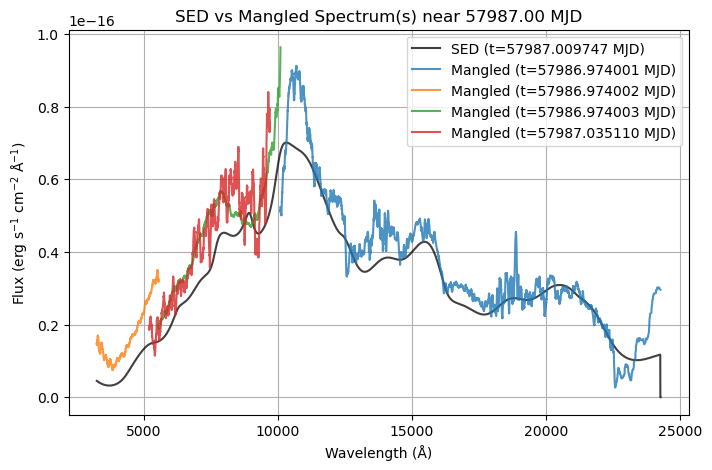

In [52]:
compare_sed_and_spectra(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file=None,
    original_spec_dir=None,
    ax=None,
    mode="mangled",
    time_window=0.5,
    z=0.00984
)

In [39]:
def plot_spectral_series(
    lookup_table,
    wavelengths,
    mjd0,
    time_interval=1.0,
    offset=True,
    overplot_mode="none",
    list_file=None,
    original_spec_dir=None,
    colors=None,
    z=0.00984,
    time_window=0.5,
    spec_dir=None,
    first_spec_mjd=None,
    max_plots=None,
    min_sep=0.05
):
    """
    Plot a spectral series from SED output spectra at specified time intervals.

    Behavior:
    - Build a regular desired-MJD grid starting at `mjd0` with spacing `time_interval`.
    - For each desired MJD, select the nearest SED output spectrum (lookup_table rows
      are days-from-first-spectrum) if that spectrum is within `time_window` days.
    - Plot modes:
        * offset=True  : vertical stacking (no numeric y-ticks), each spectrum colored
                         and labeled at the right end with its actual MJD.
        * offset=False : real flux values, colored, labeled similarly.
    - Optionally overplot input spectra ("original","smoothed","mangled") matched to
      each plotted SED spectrum (using the same time_window tolerance).
    - Colors: use provided list or matplotlib default cycle.
    - You can provide `first_spec_mjd` (absolute MJD of lookup_table index==0),
      or `spec_dir` (directory with SED files named like "57983.991400_...") to infer it.
    - min_sep : minimum vertical separation between adjacent stacked spectra (in normalized units).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import glob

    # --- determine mjd_ref (absolute MJD that corresponds to lookup_table.index == 0) ---
    if first_spec_mjd is not None:
        mjd_ref = float(first_spec_mjd)
    else:
        # prefer explicit spec_dir, else try global data_dir if available, else try common default
        spec_dir = spec_dir or globals().get("data_dir") or \
                   "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/as_observed"
        if os.path.isdir(spec_dir):
            files = sorted([os.path.basename(f) for f in os.listdir(spec_dir) if "_" in f])
            mjds = []
            for fn in files:
                try:
                    mjds.append(float(fn.split("_")[0]))
                except Exception:
                    continue
            if len(mjds) > 0:
                mjd_ref = float(min(mjds))
            else:
                print("⚠️ Couldn't infer first-spec MJD from spec_dir; using mjd0 as fallback (labels may be off).")
                mjd_ref = float(mjd0)
        else:
            print("⚠️ spec_dir not found and first_spec_mjd not provided; using mjd0 as fallback (labels may be off).")
            mjd_ref = float(mjd0)

    # absolute MJDs of SED spectra
    sed_abs_mjds = lookup_table.index.to_numpy() + mjd_ref

    # build desired MJD grid starting at mjd0
    last_mjd = np.nanmax(sed_abs_mjds)
    desired_mjds = np.arange(mjd0, last_mjd + 0.5 * time_interval, time_interval)

    # pick nearest available SED spectrum for each desired MJD within time_window
    chosen_idxs = []
    for dm in desired_mjds:
        diffs = np.abs(sed_abs_mjds - dm)
        idx = int(np.argmin(diffs))
        if diffs[idx] <= time_window:
            chosen_idxs.append(idx)
    # keep order and make unique
    chosen_idxs = list(dict.fromkeys(chosen_idxs))

    if len(chosen_idxs) == 0:
        print("No SED spectra found within the requested time window. Increase time_window or check mjd0/spec_dir.")
        return None

    # prepare colors
    if colors is None:
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    else:
        color_cycle = list(colors)

    # compute per-spectrum offsets if requested
    if offset:
        # build normalized spectra (safe against zeros/NaNs)
        norm_spectra = []
        for i in chosen_idxs:
            f = lookup_table.iloc[i].values.astype(float)
            mx = np.nanmax(f)
            if not np.isfinite(mx) or mx == 0:
                norm_spectra.append(np.zeros_like(f))
            else:
                norm_spectra.append(f / mx)

        # iterative offsets: bottom spectrum = 0; each next one is moved up so that
        # min( (cur + off_cur) - (prev + off_prev) ) >= min_sep
        offsets = np.zeros(len(norm_spectra), dtype=float)
        for k in range(1, len(norm_spectra)):
            prev = norm_spectra[k - 1]
            cur = norm_spectra[k]
            diff = cur - prev
            min_diff = np.nanmin(diff)
            # required increment to guarantee separation at all wavelengths
            inc = max(min_sep - min_diff, 0.0)
            offsets[k] = offsets[k - 1] + inc
    else:
        offsets = None
        norm_spectra = None

    # prepare input spectra if overplotting requested
    input_paths = []
    input_mjds = []
    if overplot_mode != "none":
        if overplot_mode == "smoothed":
            if list_file is None:
                list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_lists_smoothed/AT2017gfo.list"
            list_file = list_file.replace("1_spec_lists_original", "2_spec_lists_smoothed")
            if original_spec_dir is None:
                original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
        elif overplot_mode == "mangled":
            if original_spec_dir is None:
                original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/mangled_spectra"
            exts = ("*.txt", "*.dat", "*.asc", "*.spec", "*.ascii", "*.pdf")
            files = []
            for e in exts:
                files.extend(sorted(glob.glob(os.path.join(original_spec_dir, e))))
            for p in files:
                bn = os.path.basename(p)
                try:
                    m = float(bn.split("_")[0])
                    input_paths.append(p)
                    input_mjds.append(m)
                except Exception:
                    continue
        else:  # original
            if original_spec_dir is None:
                original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
            if list_file is None:
                list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list"
        if overplot_mode in ("original", "smoothed"):
            input_paths = []
            input_mjds = []
            with open(list_file) as f:
                for line in f:
                    if line.strip() == "" or line.startswith("#"):
                        continue
                    parts = line.split()
                    if overplot_mode == "smoothed":
                        if len(parts) >= 3:
                            try:
                                input_mjds.append(float(parts[0]))
                                p = parts[2]
                                p = p if p.startswith("/") else os.path.join(original_spec_dir, p)
                                input_paths.append(p)
                            except Exception:
                                continue
                    else:
                        if len(parts) >= 1:
                            try:
                                p = parts[0]
                                p = p if p.startswith("/") else os.path.join(original_spec_dir, p)
                                input_paths.append(p)
                                input_mjds.append(float(parts[-1]))
                            except Exception:
                                continue
            input_mjds = np.array(input_mjds) if input_mjds else np.array([])

    # plotting
    fig, ax = plt.subplots(figsize=(16,24))
    ax.set_xlabel("Wavelength (Å)")
    if offset:
        ax.set_ylabel("Flux (offset)")
        ax.set_yticks([])
    else:
        ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")

    for j, idx in enumerate(chosen_idxs):
        sed_flux = lookup_table.iloc[idx].values
        sed_mjd = sed_abs_mjds[idx]            # actual MJD of this spectrum
        phase_days = sed_mjd - mjd0
        color = color_cycle[j % len(color_cycle)]
        if offset:
            y_offset = offsets[j]
            plot_flux = norm_spectra[j] + y_offset
        else:
            y_offset = 0.0
            plot_flux = sed_flux

        # plot SED spectrum (no legend entry)
        ax.plot(wavelengths, plot_flux, color=color, linewidth=1.5)

        # label with actual MJD (using plotted value)
        ax.text(
            wavelengths[-1] + (wavelengths[-1] - wavelengths[0]) * 0.005,
            plot_flux[-1],
            f"{sed_mjd:.6f}",  # actual MJD with reasonable precision
            color=color,
            fontsize=9,
            verticalalignment="center"
        )

        # optionally overplot input spectrum matched by MJD
        if overplot_mode != "none" and len(input_mjds) > 0:
            diffs = np.abs(np.array(input_mjds) - sed_mjd)
            closest = int(np.argmin(diffs))
            if diffs[closest] <= time_window:
                input_path = input_paths[closest]
                try:
                    data = np.loadtxt(input_path)
                    wl = data[:, 0]
                    fl = data[:, 1]
                    if z > 0.0:
                        wl = wl / (1 + z)
                        fl = fl * (1 + z)
                    # shift overlay by same y_offset (if offsetting, overlay will likely need scaling to match)
                    ax.plot(wl, fl + y_offset, color=color, linestyle="--", alpha=0.8)
                except Exception as e:
                    print(f"Could not load/plot input spectrum: {input_path} — {e}")

        # limit number plotted if requested
        if (max_plots is not None) and (j + 1 >= max_plots):
            break

    ax.set_title(f"Spectral Series every {time_interval} d (start {mjd0:.2f} MJD)")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return ax
# ...existing code...

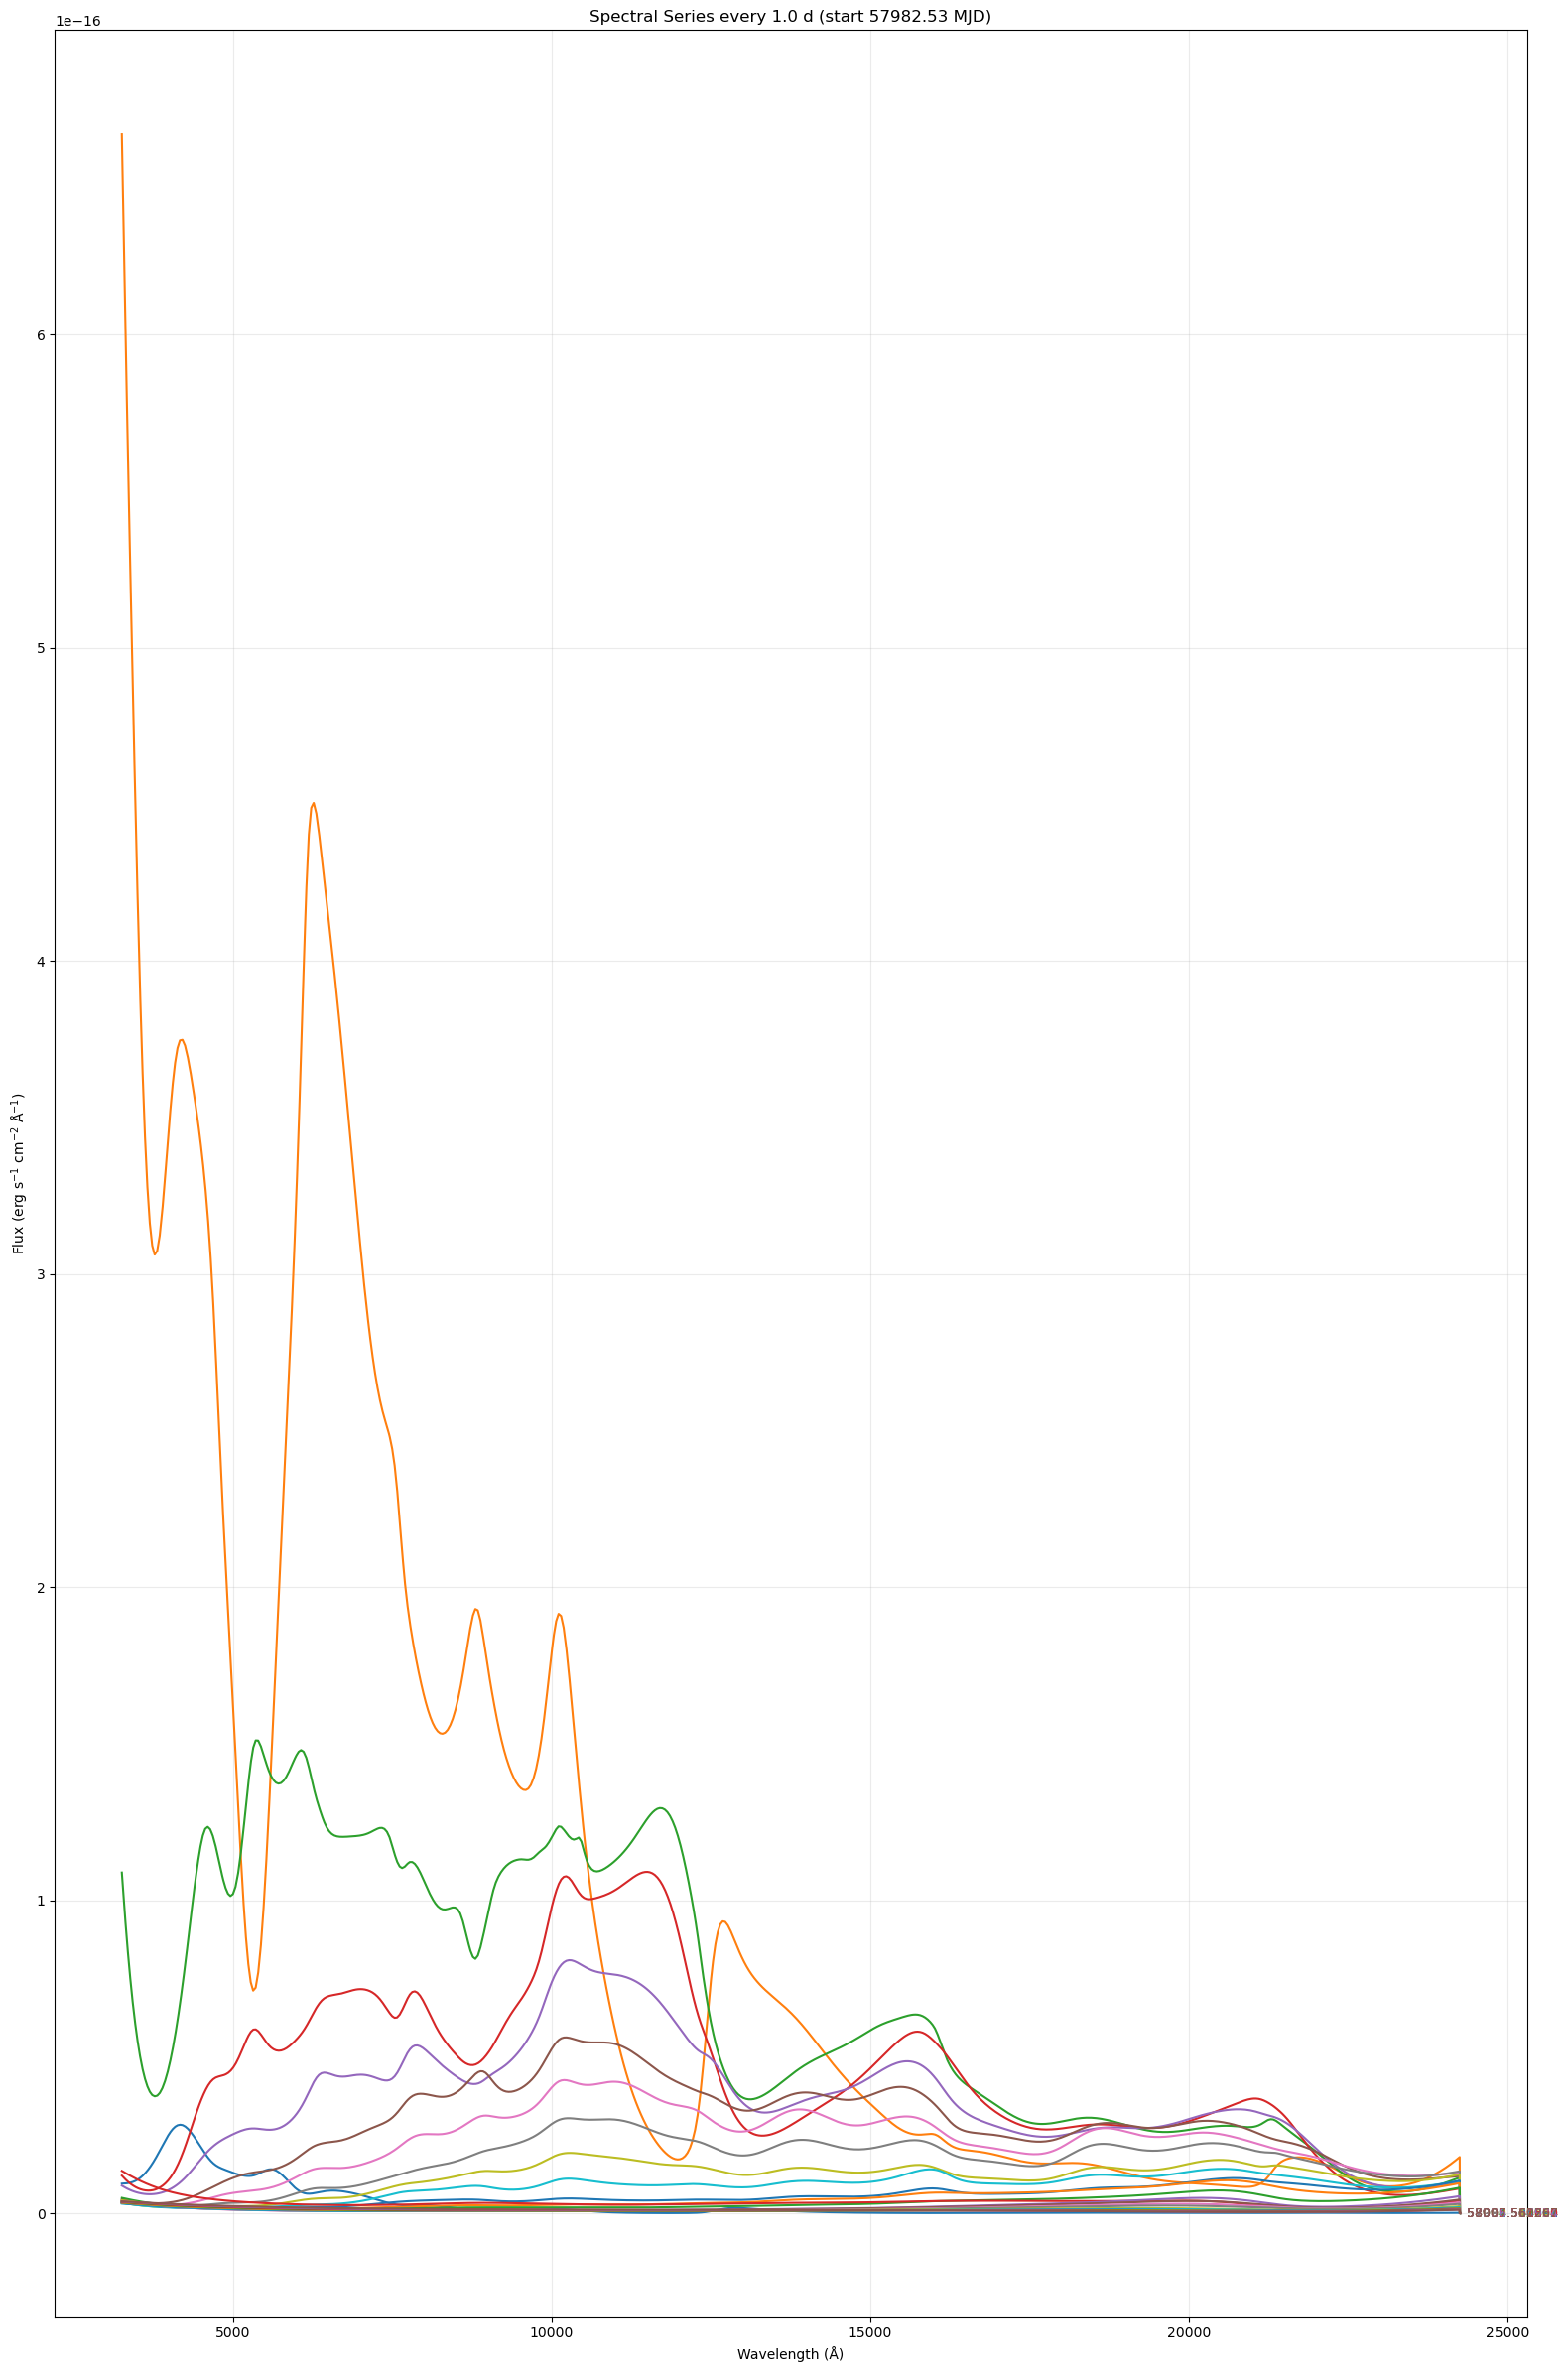

<Axes: title={'center': 'Spectral Series every 1.0 d (start 57982.53 MJD)'}, xlabel='Wavelength (Å)', ylabel='Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)'>

In [47]:
plot_spectral_series(
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    time_interval=1.0,
    offset=False,
    overplot_mode="none",
    list_file=None,
    original_spec_dir=None,
    colors=None,
    z=0.00984,
    time_window=0.5,
    spec_dir=None,
    first_spec_mjd=None,
    max_plots=None
)

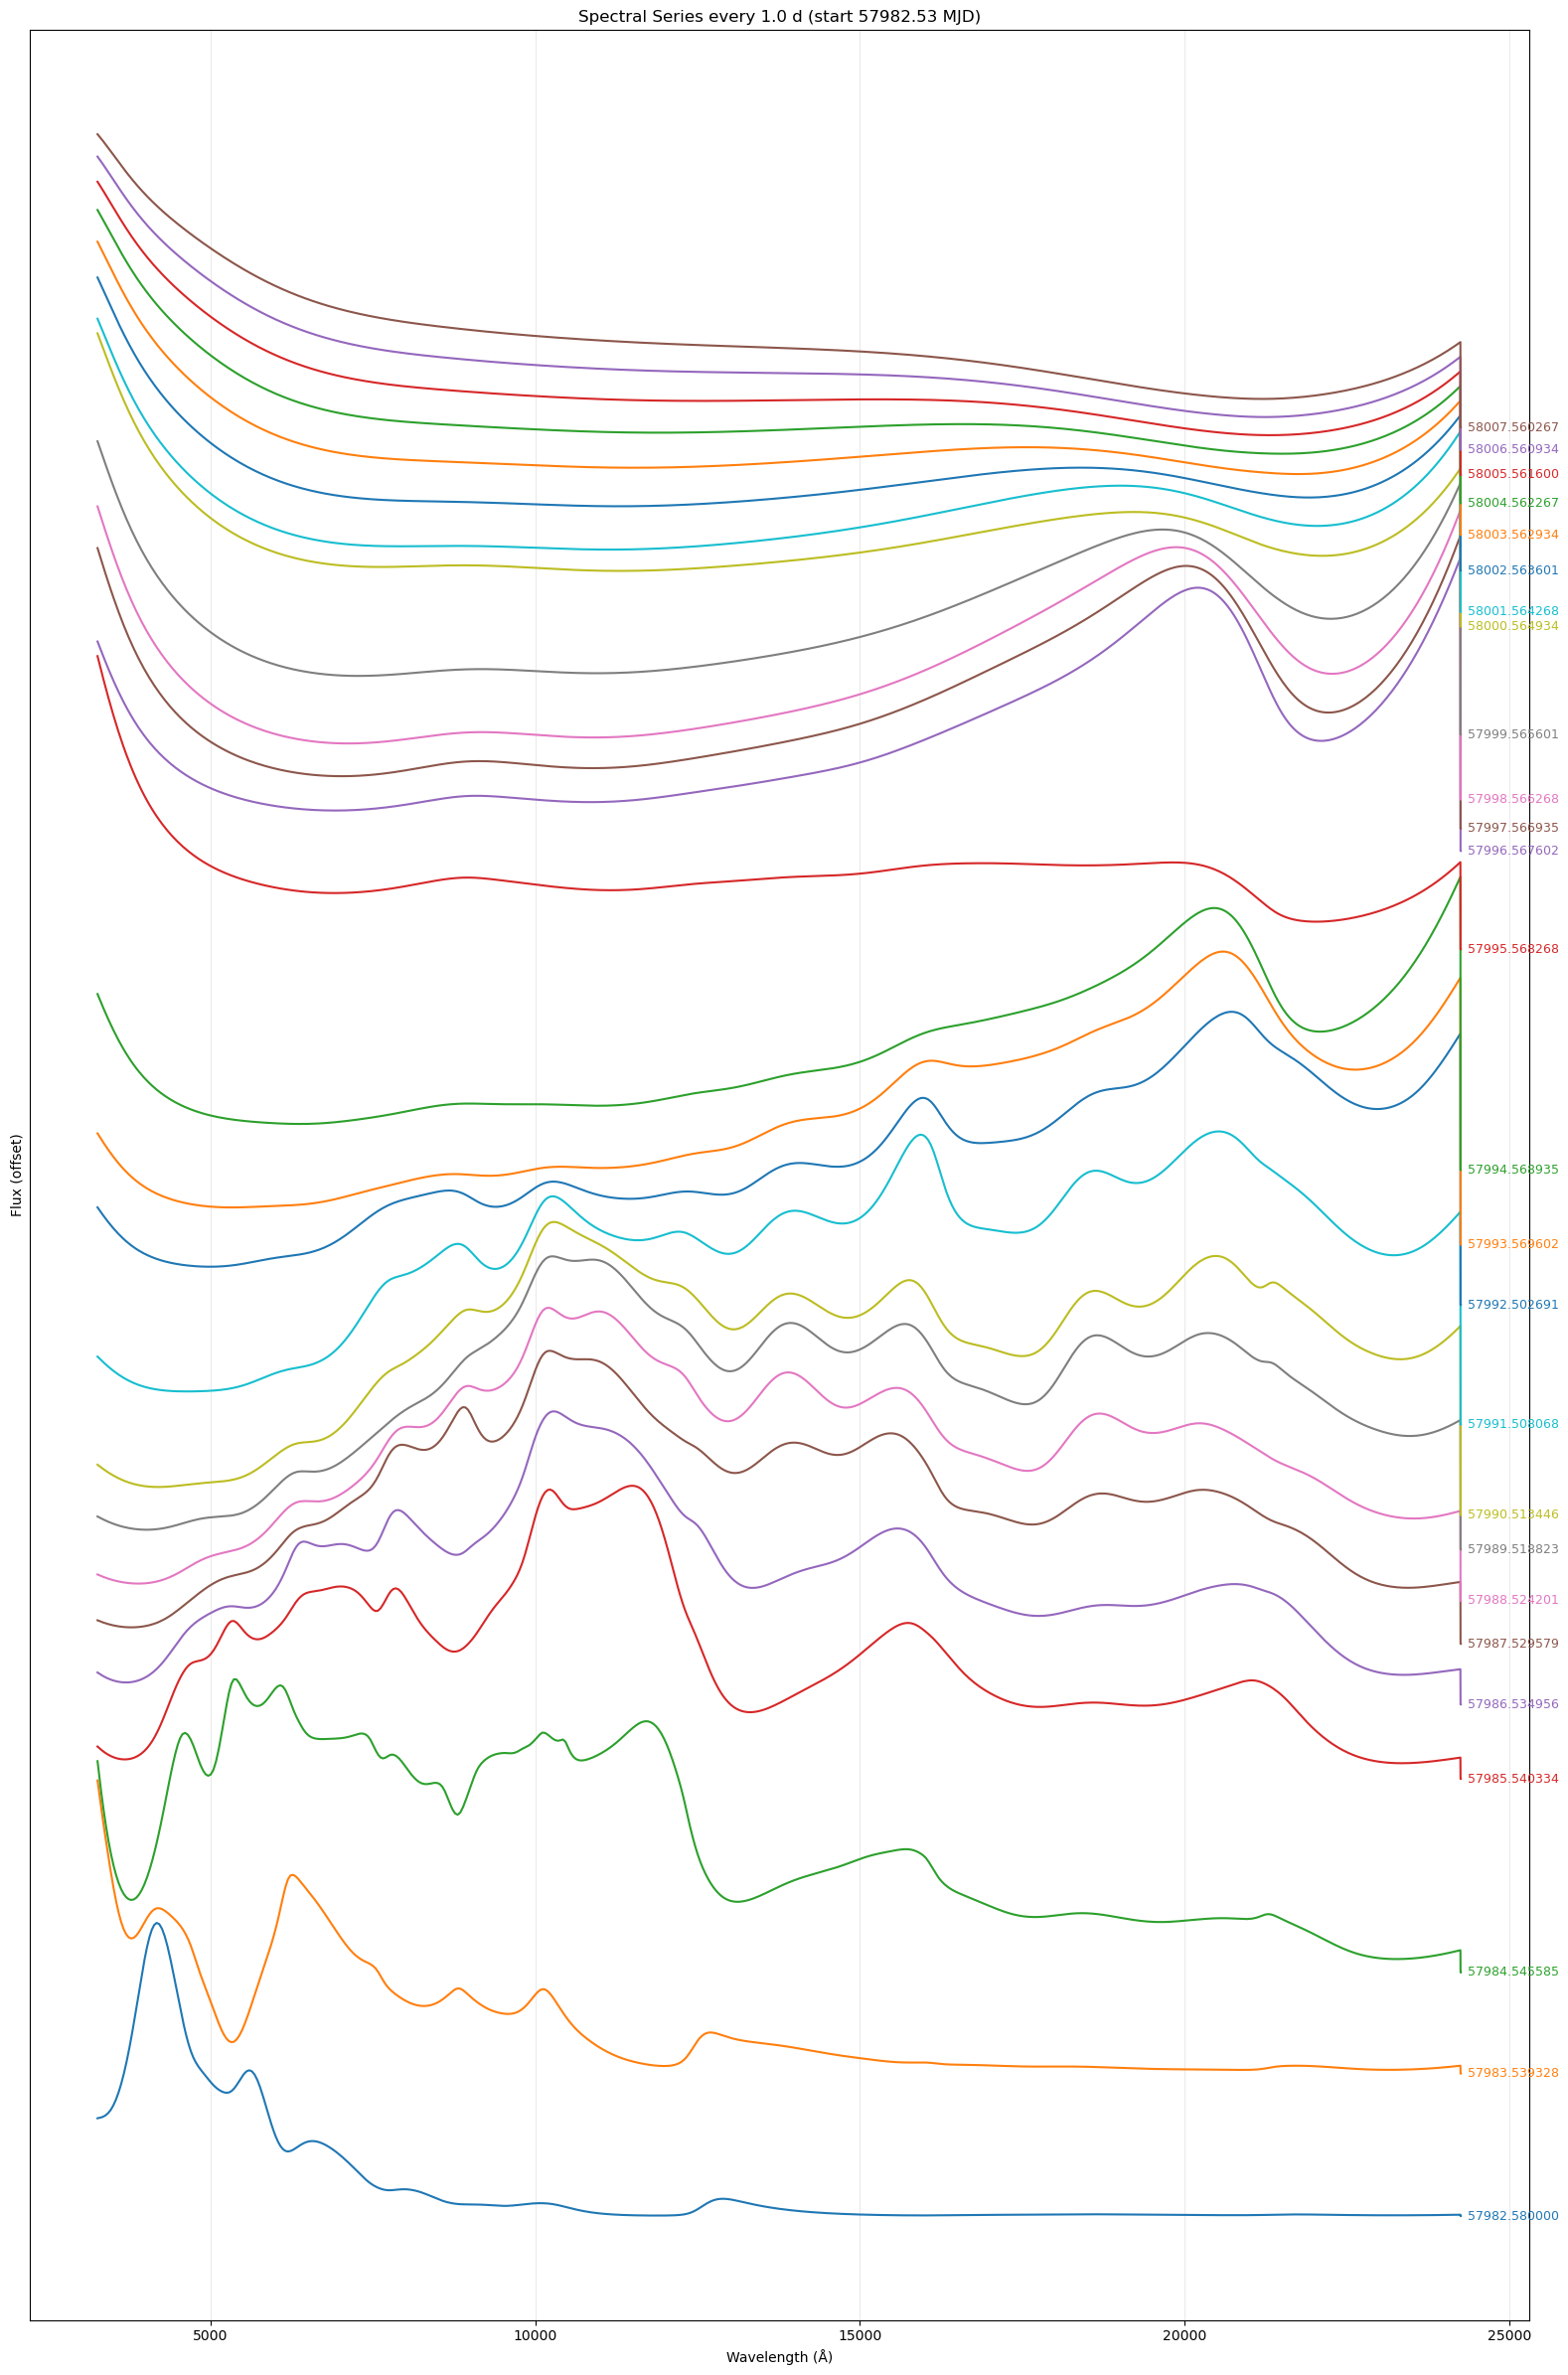

<Axes: title={'center': 'Spectral Series every 1.0 d (start 57982.53 MJD)'}, xlabel='Wavelength (Å)', ylabel='Flux (offset)'>

In [46]:
plot_spectral_series(
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    time_interval=1.0,
    offset=True,
    overplot_mode="none",
    list_file=None,
    original_spec_dir=None,
    colors=None,
    z=0.00984,
    time_window=0.5,
    spec_dir=None,
    first_spec_mjd=None,
    max_plots=None,
    min_sep=0.05
)

In [64]:
def plot_synthetic_lightcurves(
    filters,
    lookup_table=None,
    common_wavelengths=None,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    mjd0=None,
    ax=None,
    marker=None,
    linewidth=2.0,
    alpha=0.9,
    ext=".dat"
):
    """
    Plot synthetic lightcurves for a list of filters (by name or full path).

    - filters : str or list[str]
        Filter basenames (e.g. "Swope_i" or "Swope_i.dat") or full paths.
        If basename is provided, the function will look for the file in
        `filter_dir` (defaults to FILTER_PATH if available, else a sensible default).
    - lookup_table/common_wavelengths OR spectra_list : as for synthetic_lightcurve
    - system : photometric system to pass to synthetic_lightcurve ("abmag" default)
    - filter_dir : directory to search for filter files (defaults to FILTER_PATH)
    - colors : list[str], optional color list; will cycle if shorter than filters
    - labels : list[str] optional labels for inline text; defaults to filter basenames
    - mjd0 : float, optional; if provided, syn_times will be plotted as (syn_times - mjd0)
    - ax : matplotlib axis to draw on (created if None)
    - marker, linewidth, alpha : plot styling
    - ext : default extension to append to basenames if missing (".dat")
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    # allow a single string
    if isinstance(filters, str):
        filters = [filters]

    # determine search directory for filters
    if filter_dir is None:
        filter_dir = globals().get("FILTER_PATH") or (globals().get("COCO_PATH") + "Inputs/Filters/GeneralFilters/")

    # build full paths for filter files
    filter_paths = []
    filter_basenames = []
    for f in filters:
        if os.path.isabs(f) or ("/" in f):
            # given a path-like string; append extension if missing and file not found
            fp = f if f.endswith(ext) else f + ext
            if not os.path.exists(fp):
                fp = f  # keep original and let errors surface later
        else:
            # treat as basename; try with/without extension in filter_dir
            base = f if f.endswith(ext) else f + ext
            fp = os.path.join(filter_dir, base)
            if not os.path.exists(fp):
                # try without appended ext (in case user provided it already)
                alt = os.path.join(filter_dir, f)
                fp = alt if os.path.exists(alt) else os.path.join(filter_dir, base)
        filter_paths.append(fp)
        filter_basenames.append(os.path.basename(f).replace(ext, ""))

    # labels default
    if labels is None:
        labels = filter_basenames
    if colors is None:
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    else:
        color_cycle = list(colors)

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 8))

    for i, fp in enumerate(filter_paths):
        if not os.path.exists(fp):
            print(f"⚠️ filter file not found: {fp} — skipping")
            continue

        try:
            syn_times, syn_vals = synthetic_lightcurve(
                fp, system=system,
                lookup_table=lookup_table,
                common_wavelengths=common_wavelengths,
                spectra_list=spectra_list
            )
        except Exception as e:
            print(f"Could not compute synthetic LC for {fp}: {e}")
            continue

        # shift times if requested (e.g., syn_times are MJD and you want days since mjd0)
        if mjd0 is not None:
            syn_times_plot = syn_times - float(mjd0)
        else:
            syn_times_plot = syn_times

        mask = np.isfinite(syn_vals)
        if mask.sum() == 0:
            print(f"⚠️ No valid synthetic points for {fp}; skipping")
            continue

        color = color_cycle[i % len(color_cycle)]
        ax.plot(syn_times_plot[mask], syn_vals[mask],
                color=color, linewidth=linewidth, alpha=alpha, marker=marker)

        # place inline label at last valid point
        x_last = syn_times_plot[mask][-1]
        y_last = syn_vals[mask][-1]
        span = (np.nanmax(syn_times_plot[mask]) - np.nanmin(syn_times_plot[mask]))
        x_off = 0.02 * span if span > 0 else 0.1
        ax.text(x_last + x_off, y_last, labels[i], color=color, fontsize=9,
                verticalalignment="center")

    ax.set_xlabel("Time (days)" if mjd0 is not None else "Time (days from first spectrum)")
    ax.set_ylabel("Mag" if "mag" in system else "Flux / countrate")
    if "mag" in system:
        ax.invert_yaxis()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    return ax

In [72]:
filter_names = [
    'Swope_i',
    'FourStar_H',
    'FourStar_J',
    'DECam_i',
    'DECam_z',
    'DECam_Y',
    'FourStar_Ks',
    'UVOT_U',
    'Skymapper_i',
    'Sinistro_g',
    'Sinistro_r',
    'Skymapper_r',
    'Skymapper_g',
    'EFOSC2_V',
    'Sinistro_i',
    'DECam_r',
    'DECam_g',
    'DECam_u',
    'Swope_V',
    'FourStar_J1',
    'Swope_B',
    'Swope_r',
    'Swope_g',
    'EFOSC2_U',
    'Sinistro_V',
    'Sinistro_z',
    'IMACS_r',
    'LRIS_I',
    'SOFI_H',
    'SOFI_Ks',
    'VISTA_Ks',
    'VISTA_J',
    'VISTA_Y',
    'FLAMINGOS-2_Ks',
    'UVOT_M2',
    'UVOT_W1',
    'UVOT_W2',
    'HSC_z',
    'GFC_i',
    'GFC_y',
    'GFC_z',
    'GFC_r',
    'SIRIUS_H',
    'SIRIUS_J',
    'SIRIUS_Ks',
    'T80Cam_g',
    'GROND_H',
    'GROND_J',
    'GROND_K',
    'GROND_g',
    'GROND_i',
    'GROND_r',
    'GROND_z',
    'FLAMINGOS-2_H',
    'IMACS_i',
    'FLAMINGOS-2_J',
    'UVOT_B',
    'GMOS_g',
    'GMOS_i',
    'GMOS_r',
    'GMOS_z',
    'FORS2_R',
    'VIMOS_z',
    'FORS2_I',
    'FORS2_B',
    'FORS2_V',
    'ANDICAM_K',
    'MOIRCS_Ks',
    'HAWKI_Ks'
]

  points: [11376.36591589 11378.4660258  11380.56613571 11382.66624562
 11384.76635554 11386.86646545 11388.96657536 11391.06668527
 11393.16679518 11395.26690509 11397.367015   11399.46712491
 11401.56723482 11403.66734473 11405.76745465 11407.86756456
 11409.96767447 11412.06778438 11414.16789429 11416.2680042
 11418.36811411 11420.46822402 11422.56833393 11424.66844384
 11426.76855376 11428.86866367 11430.96877358 11433.06888349
 11435.1689934  11437.26910331 11439.36921322 11441.46932313
 11443.56943304 11445.66954295 11447.76965287 11449.86976278
 11451.96987269 11454.0699826  11456.17009251 11458.27020242
 11460.37031233 11462.47042224 11464.57053215 11466.67064206
 11468.77075198 11470.87086189 11472.9709718  11475.07108171
 11477.17119162 11479.27130153 11481.37141144 11483.47152135
 11485.57163126 11487.67174117 11489.77185109 11491.871961
 11493.97207091 11496.07218082 11498.17229073 11500.27240064
 11502.37251055 11504.47262046 11506.57273037 11508.67284028
 11510.7729502  1

Could not compute synthetic LC for /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Filters/GeneralFilters/UVOT_M2.dat: Source spectrum and bandpass are disjoint.


<Axes: xlabel='Time (days)', ylabel='AB mag'>

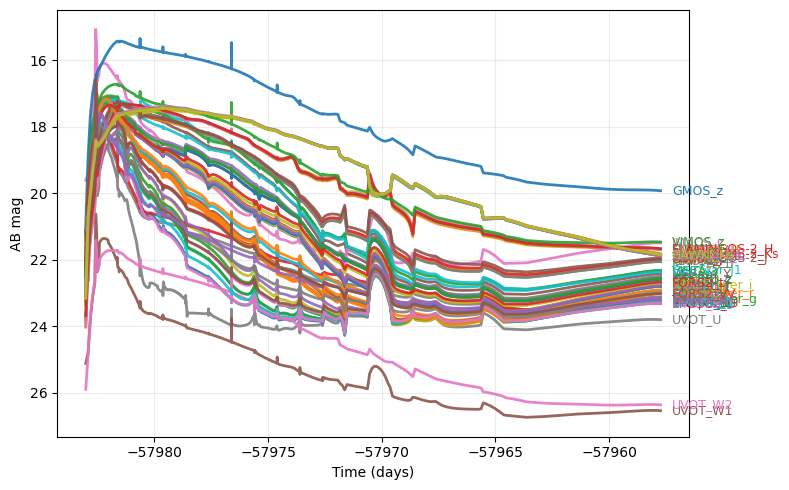

In [69]:
plot_synthetic_lightcurves(
    filters=filter_names,
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    mjd0=57983.01825,
    ax=None,
    marker=None,
    linewidth=2.0,
    alpha=0.9,
    ext=".dat")

  points: [11376.36591589 11378.4660258  11380.56613571 11382.66624562
 11384.76635554 11386.86646545 11388.96657536 11391.06668527
 11393.16679518 11395.26690509 11397.367015   11399.46712491
 11401.56723482 11403.66734473 11405.76745465 11407.86756456
 11409.96767447 11412.06778438 11414.16789429 11416.2680042
 11418.36811411 11420.46822402 11422.56833393 11424.66844384
 11426.76855376 11428.86866367 11430.96877358 11433.06888349
 11435.1689934  11437.26910331 11439.36921322 11441.46932313
 11443.56943304 11445.66954295 11447.76965287 11449.86976278
 11451.96987269 11454.0699826  11456.17009251 11458.27020242
 11460.37031233 11462.47042224 11464.57053215 11466.67064206
 11468.77075198 11470.87086189 11472.9709718  11475.07108171
 11477.17119162 11479.27130153 11481.37141144 11483.47152135
 11485.57163126 11487.67174117 11489.77185109 11491.871961
 11493.97207091 11496.07218082 11498.17229073 11500.27240064
 11502.37251055 11504.47262046 11506.57273037 11508.67284028
 11510.7729502  1

Could not compute synthetic LC for /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Filters/GeneralFilters/UVOT_M2.dat: Source spectrum and bandpass are disjoint.


<Axes: xlabel='Time (days from first spectrum)', ylabel='Mag'>

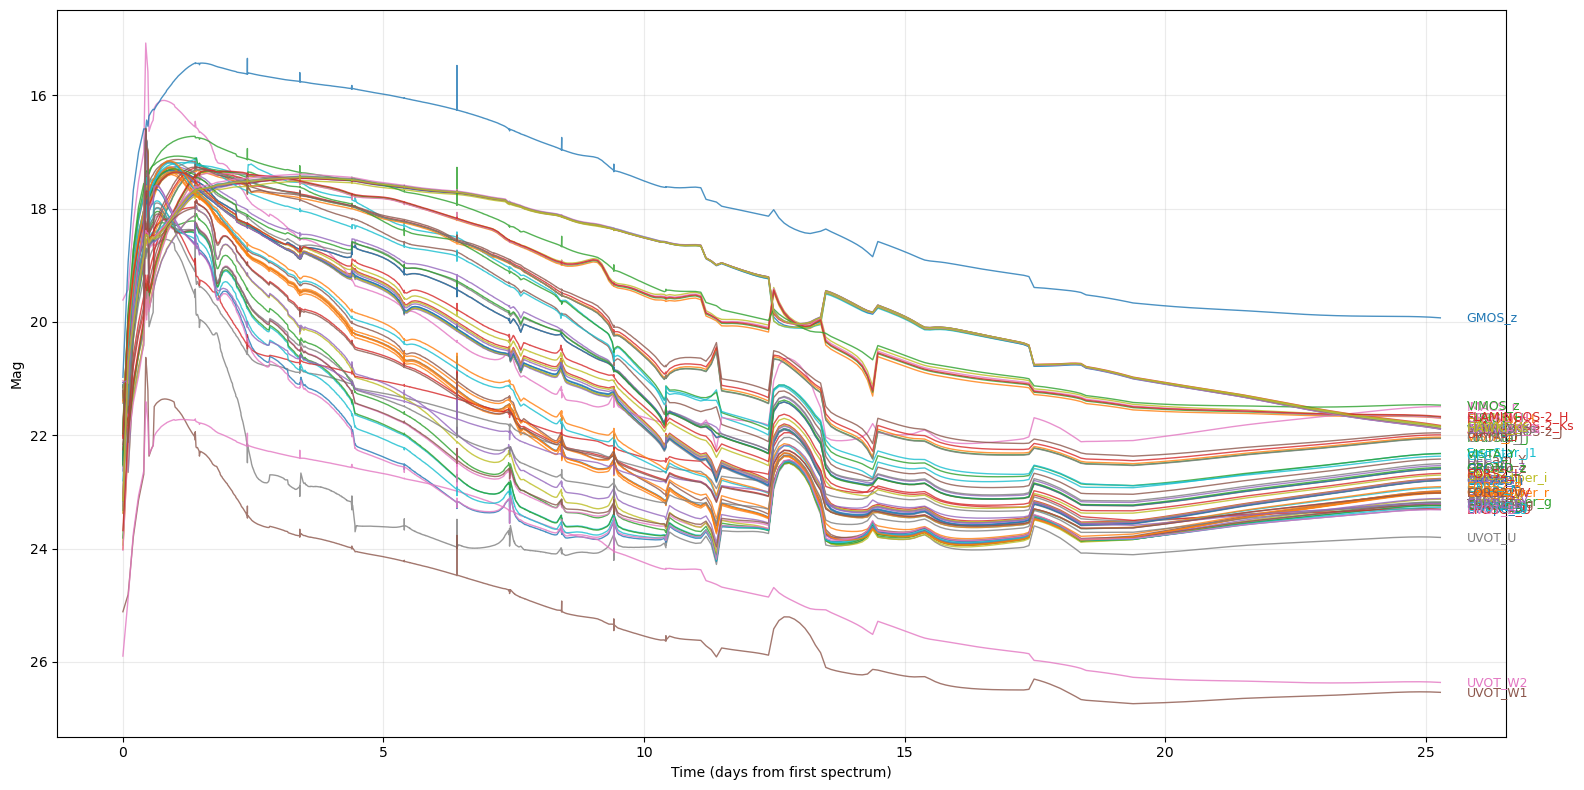

In [73]:
plot_synthetic_lightcurves(
    filters=filter_names,
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    mjd0=None,
    ax=None,
    marker=None,
    linewidth=1.0,
    alpha=0.8,
    ext=".dat")

In [62]:
swope = [
    'Swope_i',
    'Swope_V',
    'Swope_B',
    'Swope_r',
    'Swope_g'
]

fourstar = [
    'FourStar_H',
    'FourStar_J',
    'FourStar_Ks',
    'FourStar_J1'
]

decam = [
    'DECam_i',
    'DECam_z',
    'DECam_Y',
    'DECam_r',
    'DECam_g',
    'DECam_u'
]

uvot = [
    'UVOT_U',
    'UVOT_M2',
    'UVOT_W1',
    'UVOT_W2',
    'UVOT_B'
]

skymapper = [
    'Skymapper_i',
    'Skymapper_r',
    'Skymapper_g'
]

sinistro = [
    'Sinistro_i',
    'Sinistro_V',
    'Sinistro_z'
]

efosc2 = [
    'EFOSC2_V',
    'EFOSC2_U'
]

imacs = [
    'IMACS_r',
    'IMACS_i'
]

lris = [
    'LRIS_I'
]

sofi = [
    'SOFI_H',
    'SOFI_Ks'
]

vista = [
    'VISTA_Ks',
    'VISTA_J',
    'VISTA_Y'
]

flamingos = [
    'FLAMINGOS-2_Ks',
    'FLAMINGOS-2_H',
    'FLAMINGOS-2_J'
]

hsc = [
    'HSC_z'
]

gfc = [
    'GFC_i',
    'GFC_y',
    'GFC_z',
    'GFC_r'
]

sirius = [
    'SIRIUS_H',
    'SIRIUS_J',
    'SIRIUS_Ks'
]

t80cam = [
    'T80Cam_g'
]

grond = [
    'GROND_H',
    'GROND_J',
    'GROND_K',
    'GROND_g',
    'GROND_i',
    'GROND_r',
    'GROND_z'
]

gmos = [
    'GMOS_g',
    'GMOS_i',
    'GMOS_r',
    'GMOS_z'
]

fors2 = [
    'FORS2_R',
    'FORS2_I',
    'FORS2_B',
    'FORS2_V'
]

vimos = [
    'VIMOS_z'
]

other_kband = [
    'ANDICAM_K',
    'MOIRCS_Ks',
    'HAWKI_Ks'
]

<Axes: xlabel='Time (days from first spectrum)', ylabel='Mag'>

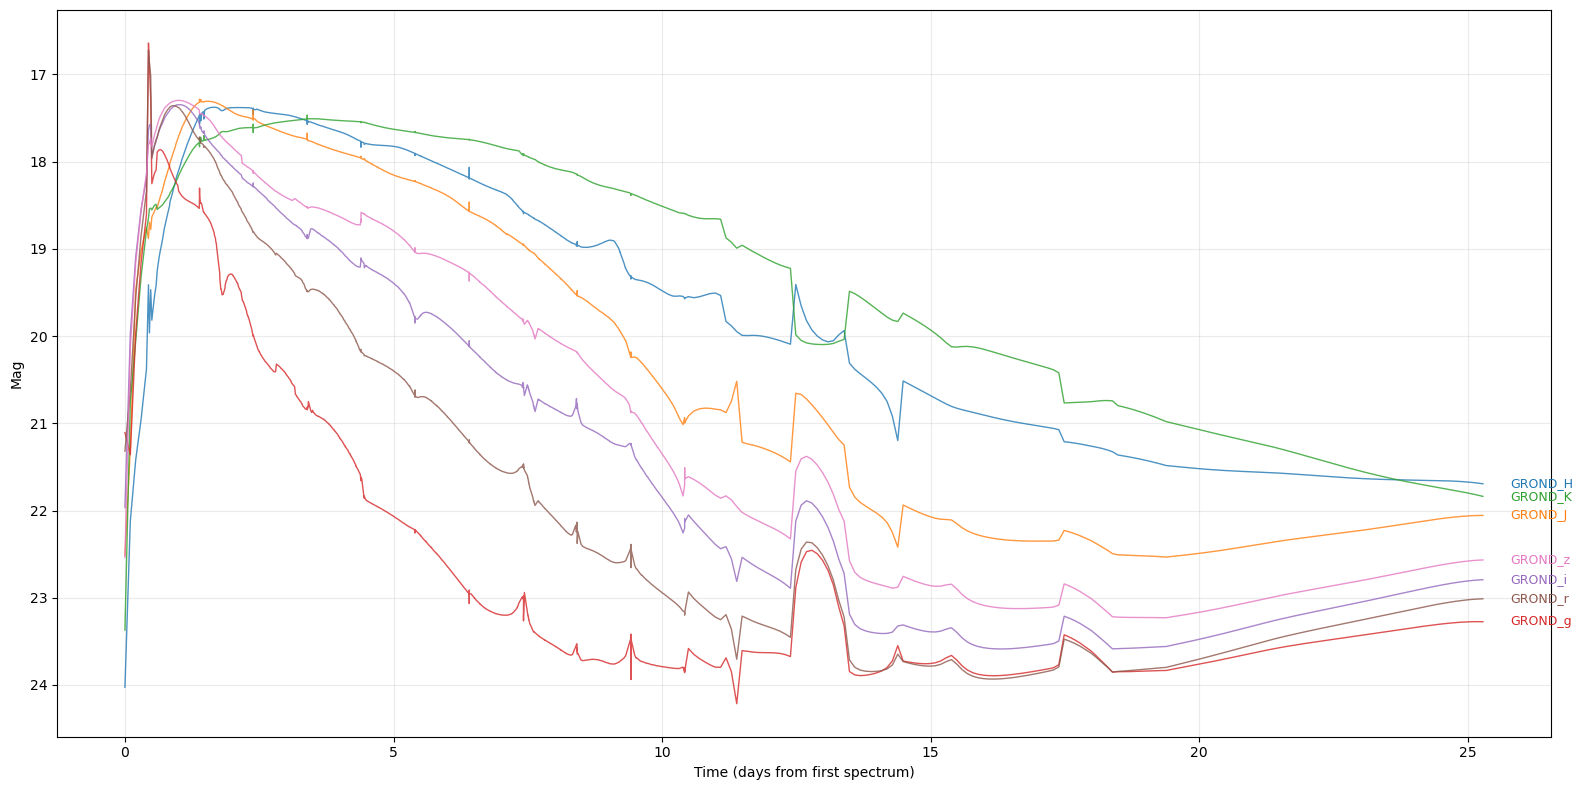

In [67]:
plot_synthetic_lightcurves(
    filters=grond,
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    #mjd0=57982.52851852,
    ax=None,
    marker=None,
    linewidth=1.0,
    alpha=0.8,
    ext=".dat")